# Обнаружение радиоактивных источников в данных RADAI: matched-фильтр и классификаторы спектральных окон

**Постановка задачи.** Рассматривается бинарное обнаружение источника гамма-излучения («в окне присутствует источник / не присутствует») на наборе данных `training_v4.3.h5` (LBNL RADAI, 300 прогонов движущегося детектора).

**Результаты** приведены для тестовых прогонов 25–124 (943 встречи). Тревогой считается эпизод превышения порога. Порог калибруется по фоновым окнам с dmin > 150 с из всех прогонов, кроме оцениваемого; метки источников не используются.

| FAR, 1/ч | LogReg | XGBoost | NN (MLP) | bestA (1 окно, 2 с) | **mx31 (итоговый детектор)** |
|---|---|---|---|---|---|
| ≈1 | 6.9 % | 9.9 % | 4.7 % | 21.2 % | **25.2 % [22.6–27.9]** |
| ≈3 | 17.5 % | 18.6 % | 12.9 % | 28.1 % | **40.5 % [37.5–44.2]** |
| ≈10 | 38.7 % | 27.7 % | 31.7 % | 37.0 % | **70.0 % [66.8–73.5]** |
| 20–100 (рабочая область гибрида, §3.5) | — | — | — | — | **85→99 % (mx31 OR MLP)** |

Доверительные интервалы (95 %) получены бутстрэпом по прогонам (run-cluster bootstrap). Для mx31 существует верхняя граница частоты ложных тревог, ≈13 эпизодов в час, обусловленная определением тревоги как эпизода. В области более высоких FAR применяется гибрид mx31 и ML-классификатора (§3.5).

## 0. Введение: задача, данные, метод

### 0.1 Постановка задачи

Детектор, установленный на транспортном средстве, представляет собой сцинтилляционный кристалл NaI(Tl): каждый зарегистрированный гамма-квант вызывает вспышку, по которой определяются его энергия и момент регистрации. Данные представлены в формате list-mode, то есть как поток отдельных событий, а не как усреднённая скорость счёта. Транспортное средство движется по смоделированному городу; файл данных содержит набор таких поездок.

Городская среда сама радиоактивна: K-40 в бетоне и грунте, урановый и ториевый ряды и продукты их распада (Pb-214, Bi-214), Cs-137 в почве, космические мюоны. Этот **фон** создаёт порядка 2600 регистрируемых квантов в секунду. **Сигнал** порождается скрытым источником (например, Cs-137 или Co-60), мимо которого проезжает транспортное средство. Требуется выдавать тревогу при проезде мимо источника и не выдавать её в его отсутствие.

В работе используются два основных показателя (остальные термины приведены в §0.3):

* **FAR (false alarm rate)** — число ложных тревог в час движения по фону, которое допускается для алгоритма. Это основное практическое ограничение: система, выдающая тревогу каждые пять минут, непригодна к эксплуатации.
* **Recall (полнота обнаружения)** — доля встреч с источником, зафиксированных алгоритмом.

Трудность задачи обусловлена тем, что вариации фона от окна к окну превышают вклад источника. При смене улицы скорость счёта может вырасти в несколько раз без какого-либо источника, поэтому модель, реагирующая на превышение счёта, фактически различает участки маршрута, а не источники. Отношение сигнал/шум (**SNR**), то есть отношение числа квантов источника к стандартному отклонению флуктуаций фона, для большинства встреч составляет единицы, а вклад источника в двухсекундное окно — доли процента от полного счёта (численная иллюстрация для одного прогона приведена в §1). Вследствие этого классификаторы, обученные на спектрах окон, показывают ROC-AUC 0.53–0.65 (§2), тогда как значение 0.5 соответствует случайному угадыванию. При практически приемлемом бюджете тревог (FAR 1–10/ч) recall таких классификаторов составляет 4.7–38.7 % (§2, таблица выше), то есть значительная часть встреч остаётся необнаруженной.

### 0.2 Структура файла данных

`training_v4.3.h5` (около 26.6 ГБ, формат HDF5) — публичный бенчмарк LBNL RADAI ([bdc.lbl.gov](https://bdc.lbl.gov/wiki/public/radai-interactive-datasets/)), содержащий симулированные проезды детектора по городу. Файл включает 300 прогонов (`runs/run0` … `runs/run299`). Каждый прогон соответствует часовой поездке (около 3616 с, 9.0–9.6 млн зарегистрированных квантов). В работе использовано 123 прогона: 18 обучающих (0, 3–19), 5 валидационных (20–24) и 100 тестовых (25–124); остальные прогоны не задействованы.

Абсолютное время регистрации кванта в файле не хранится: для каждого кванта указан интервал `dt` до предыдущего события. Время от начала прогона восстанавливается накоплением: `t = cumsum(dt)/1e6` (с). Внутри каждого прогона данные разделены на четыре группы:

| путь в `runs/run{i}/` | dtype | содержание |
|---|---|---|
| `listmode/dt` | uint16 | интервал от предыдущего кванта, мкс |
| `listmode/energy` | float32 | энергия кванта, кэВ (0…7000, среднее ≈324) |
| `listmode/id` | uint16 | идентификатор источника, испустившего квант; **0 — квант фона** (99.8 % всех квантов) |
| `listmode/background_id` | uint8 | для фоновых квантов — номер компоненты фона; для квантов источника совпадает с `id` |
| `sources/id` | uint16 | идентификатор источника; расшифровка — в корневом атрибуте `source_names` |
| `sources/time` | uint32 | время от начала прогона до точки наибольшего сближения (CA), мс |
| `sources/distance` | float32 | расстояние в точке наибольшего сближения, м (от сотен до тысяч) |
| `sources/activity` | float32 | активность, Бк (от единиц до 1e8) |
| `sources/shielding` | uint16 | идентификатор экранирования (корневой атрибут `source_shielding_names`: None, 0.025cm_steel, …) |
| `sources/standoff` | float32 | удаление источника от дороги (standoff), м; в файле встречаются отрицательные значения |
| `sources/location_id` | uint16 | идентификатор места размещения источника |
| `sources/snr/{peak,integral}` | float32 | «пиковое SNR» встречи; точное определение в документации не приводится, поле `integral` помечено как устаревшее (Deprecated, совпадает с `peak`), см. §4.4 |
| `detector/position/{time,velocity,acceleration,distance}` | uint32/float32 | траектория детектора, 10 Гц; в детекторе не используется (попытка построить пространственную карту фона оказалась безрезультатной, §5) |
| `diagnostics/*` | float32 | показатели стабильности аппаратуры, 1 Гц, 3600 отсчётов; не используются |

Длины массивов `listmode/*` равны числу квантов прогона, длины `sources/*` — числу источников в нём (от 5 до 13, в среднем около 9). Корневые атрибуты содержат словари имён: `source_names` (73 имени вида `Cs-137_shielding_id=2`; идентификатор 0 соответствует фону BKG), `background_names` (8 имён: Src, K-40, U, Th, Cs137_Soil, Pb-214, Bi-214, Cosmics; индекс 0 зарезервирован, а у фоновых квантов `background_id` принимает значения 1–7) и `source_shielding_names`. Описания полей приведены в атрибутах самого файла (например, «elapsed time since last photon detection event (microseconds)»).

**Встреча** (encounter) соответствует ситуации, когда источник находится у дороги, а транспортное средство проезжает мимо: вклад источника нарастает и спадает в течение десятков секунд вокруг CA. Один прогон содержит от 5 до 13 встреч; они служат положительными примерами и единицей учёта recall (интервал CA ± 60 с).

Состав фона в run0 по `background_id`: U-ряд ≈55 %, Th-ряд ≈28 %, K-40 ≈17 %, космическое излучение ≈0.8 %, Cs-137 в грунте ≈0.03 %. Отсюда следует принципиальная трудность: если «источником» является сам K-40 или торий (NORM-материалы), форма его спектра неотличима от фона, который из этих компонент состоит (§4.1).

### 0.3 Используемые термины

* **FAR** — число ложных тревог в час движения по фону.
* **Recall / PD** — доля реальных встреч, обнаруженных детектором.
* **SNR** — отношение сигнал/шум: отношение числа квантов источника к стандартному отклонению флуктуаций фона.
* **Встреча (encounter)** — один проезд детектора мимо одного источника.
* **Эпизод** — связный интервал времени, на котором статистика превышает порог. Тревогой считается только первое окно эпизода, чтобы одно длительное превышение не порождало множество тревог.
* **CA (closest approach)** — точка наибольшего сближения с источником (поле `sources/time`).
* **dmin** — временное расстояние от окна до ближайшей точки CA в том же прогоне; окна с большим dmin считаются фоновыми.
* **Пуассоновская подгонка** — подбор амплитуд заданных спектральных форм методом максимального правдоподобия в предположении пуассоновской статистики (для отсчётов дисперсия равна математическому ожиданию).
* **Остаток и z-оценка** — остаток равен разности наблюдаемого спектра и модели фона; z-оценка — остаток, нормированный на ожидаемое флуктуационное отклонение (выражается в «сигмах»).
* **Компонента фона** — одна из 7 типичных спектральных форм городского фона.
* **Шаблон (template)** — ожидаемая форма спектра конкретного изотопа в данном детекторе.
* **NORM** — природные радиоактивные материалы (K-40, Th-232, Ra-226); наиболее трудная для обнаружения группа.
* **U-family** — урановые материалы (DU, LEU, NatU, RefinedU); по форме спектра также неотличимы от фона.
* **Бутстрэп-интервал [a–b]** — 95 %-й доверительный интервал: прогоны многократно выбираются с возвращением, метрика вычисляется заново, границами служат 2.5-й и 97.5-й процентили.
* **B_loo** — протокол калибровки порога, при котором фоновый пул для каждого оцениваемого прогона формируется из всех остальных прогонов (leave-one-run-out).

### 0.4 Близкие работы

**Adaptive NMF (LBNL; Jones et al., [arXiv 2507.10715](https://arxiv.org/abs/2507.10715)).** Работа посвящена проблеме устаревания заранее подогнанной модели фона при попадании детектора в новую среду (другой город, осадки, радон), из-за чего частота ложных тревог дрейфует. Базис фона непрерывно пересчитывается по входящему потоку методом неотрицательной матричной факторизации; отдельный регуляризатор подавляет чувствительность модели к NORM-подобным спектральным формам, и платой за стабильность FAR становится потеря чувствительности к NORM. В настоящей работе, в отличие от Adaptive NMF, фон фиксирован (7 компонент, однократно определённых по обучающим прогонам), а статистика проще: используется проекция остатка на шаблоны, а не совместное отношение правдоподобия гипотез «фон + источник» и «только фон».

**Waterfall-CNN (PNNL; Bachleda et al., [arXiv 2607.00270](https://arxiv.org/html/2607.00270v3)).** Цель авторов — отказаться от ручного построения физических признаков. Стопка спектров во времени («водопад») подаётся в свёрточную сеть как набор каналов, а дисбаланс классов учитывается функцией потерь Focal Loss. По сообщению авторов, при мягких ограничениях на число тревог NORM обнаруживаются примерно в 20 раз чаще, чем методами NMF, а при жёстких сеть уступает физическим методам. В настоящей работе сквозное обучение не применяется: каждый элемент детектора (формы фона, изотопные шаблоны, пуассоновская подгонка) допускает физическую интерпретацию. В §4.6 выполнена проверка идеи Waterfall-CNN в уменьшенном масштабе.

Алгоритм mx31 принадлежит к тому же семейству, что и Adaptive NMF (физическая модель фона плюс шаблоны), но не содержит адаптации фона и использует более простую статистику. От Waterfall-CNN он отличается отсутствием обучения на «сыром» спектрально-временном представлении.

### 0.5 Описание метода

**Matched-фильтр** (согласованный фильтр) сравнивает наблюдаемый спектр с библиотекой известных форм. Детектор получает окно — гистограмму энергий квантов. Вопрос ставится не как «превышает ли счёт обычный уровень» (такой подход, как показано в §0.1, не работает), а как «на какую из известных форм похож *избыток* относительно фона».

Алгоритм состоит из следующих шагов (реализация — в §3.1–3.2):

1. **Модель фона.** Используются 7 типичных спектральных форм городского фона, определённых по симуляционным меткам `background_id` на обучающих прогонах. Для каждого окна амплитуды этих форм подбираются по самому окну (пуассоновская EM-подгонка). Тем самым обеспечивается самонормировка: существенна форма фона, а не его абсолютный уровень на данном участке маршрута.
2. **Остаток и проекции.** Остаток равен разности наблюдаемого спектра и подогнанного фона. Для каждого из 61 изотопного шаблона вычисляется проекция остатка на шаблон, нормированная на ожидаемое флуктуационное отклонение (z-оценка). Оценка окна (score) равна максимуму z по шаблонам, то есть показывает, насколько отклонение от фона похоже на наиболее подходящий источник.
3. **Агрегирование (mx31).** Проезд мимо источника длится десятки секунд, поэтому решение по одному окну неустойчиво. В качестве итоговой статистики берётся максимум score по последним 31 окну (62 с).
4. **Порог.** Порог определяется по числу эпизодов на фоновом пуле и калибруется на целевую частоту ложных тревог (§3.3).

In [1]:
import os, time, pickle
os.makedirs("_scratch", exist_ok=True)
os.makedirs("figures", exist_ok=True)
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

H5 = "training_v4.3.h5"
TRAIN_RUNS = [0] + list(range(3, 20))
VAL_RUNS   = [20, 21, 22, 23, 24]
TEST_RUNS  = list(range(25, 125))
ALL_RUNS   = TRAIN_RUNS + VAL_RUNS + TEST_RUNS
SNR_BINS = [(0, 5), (5, 8), (8, 12), (12, 99)]
def snr_bin(x): return next(f"{lo}-{hi}" for lo, hi in SNR_BINS if lo <= x < hi)
print("runs:", len(TRAIN_RUNS), "train /", len(VAL_RUNS), "val /", len(TEST_RUNS), "test")

runs: 18 train / 5 val / 100 test


## 1. Физические ограничения оконных классификаторов

Три диагностических наблюдения на данных (подробная проверка выполнена в скриптах `_scratch/verify*.py`):

1. **Фон нестационарен в пространстве.** Разброс суммарного счёта в двухсекундных окнах одного прогона в 30–60 раз превышает пуассоновский, автокорреляция при лаге 1 составляет ≈0.97 (время декорреляции ≈20 с). Временные базовые линии (медиана или экспоненциальное скользящее среднее по предыдущим окнам) не позволяют предсказать пространственные изменения уровня фона.
2. **Форма спектра фона почти постоянна.** Около 97 % дисперсии спектров «фоновых» окон объясняется одним глобальным профилем, умноженным на локальную скорость счёта. Следовательно, нормировку следует выполнять *по форме внутри самого окна*, а не по предшествующему времени.
3. **Поле `sources/snr` не характеризует наблюдаемость источника в окне.** В ячейке ниже для встреч с различными значениями snr вычисляется, сколько квантов источника фактически попадает в двухсекундное окно у точки сближения.

In [2]:
f = h5py.File(H5, "r")
g = f["runs/run25"]
dt = g["listmode/dt"][:]; t = np.cumsum(dt, dtype=np.uint64)/1e6
eid = g["listmode/id"][:]
snr = g["sources/snr/peak"][:]; stime = g["sources/time"][:]/1e3
src_t = t[eid != 0]
rows = []
for j in np.argsort(-snr):
    win = (src_t > stime[j]-1) & (src_t < stime[j]+1)
    tot60 = (src_t > stime[j]-30) & (src_t < stime[j]+30)
    rows.append(dict(snr=round(float(snr[j]),1), src_counts_2s_at_CA=int(win.sum()),
                     src_counts_60s=int(tot60.sum()),
                     bg_counts_2s_typ=int(0)))
tot = ((t>0)&(t<2)).sum()
df3 = pd.DataFrame(rows).head(10); df3["bg_counts_2s_typ"] = tot
print(f"run25: всего ~{tot} событий в первых 2 с (почти всё — фон)")
df3

run25: всего ~2698 событий в первых 2 с (почти всё — фон)


,snr,src_counts_2s_at_CA,src_counts_60s,bg_counts_2s_typ
0,19.4,1391,12181,2698
1,11.5,1003,2471,2698
2,10.1,1098,4472,2698
3,10.0,549,3549,2698
4,9.6,907,1225,2698
5,7.7,376,868,2698
6,6.4,371,3975,2698
7,5.6,546,1561,2698
8,3.4,269,2661,2698
9,3.0,316,726,2698


В таблице приведены 10 встреч прогона run25, упорядоченные от наибольшего значения поля `snr` к наименьшему. Столбец `src_counts_2s_at_CA` — число квантов данного источника в двухсекундном окне у точки сближения; `src_counts_60s` — число квантов за минуту вокруг CA; `bg_counts_2s_typ` — полное число квантов в двухсекундном окне (практически целиком фоновых).

Даже для встреч с наибольшими значениями snr (10–19) источник даёт в двухсекундном окне у CA около 0.5–1.4 тыс. отсчётов на фоне нескольких тысяч фоновых, а для встреч с snr ≈ 3–8 — порядка 300. В отдельных каналах спектра это составляет доли процента от фона, так что SNR формы в окне равно ≈1–3. Следовательно, любая модель, оценивающая отдельное двухсекундное окно, ограничена физически, а оконные ROC-AUC и PR-AUC слабо отражают реальную обнаруживаемость.

## 2. Базовые модели: LogReg, XGBoost и нейронная сеть на спектрах окон

Рассматриваются классификаторы, обучаемые на двухсекундных окнах: спектр из 256 бинов, равномерных по √E, с преобразованием log1p. Положительная метка присваивается окну, в котором есть хотя бы один квант источника (`listmode/id != 0`). Обучение выполняется на обучающих прогонах, ранняя остановка и отбор модели — на валидационных (20–24), оценка — на тестовых (25–124).

Вычисляются оконные ROC-AUC и PR-AUC, а также recall по встречам при значении FAR, откалиброванном по обучающим окнам вдали от CA (dmin > 150 с; тревогой считается эпизод).

In [3]:
import os, pickle, time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

EMIN, EMAX, NB2, WS = 15.0, 3000.0, 256, 2.0
smin, smax = np.sqrt(EMIN), np.sqrt(EMAX)

def build_windows(rid, nb=NB2):
    gg = f[f"runs/run{rid}"]
    dt = gg["listmode/dt"][:]; e = gg["listmode/energy"][:]; eid = gg["listmode/id"][:]
    t = np.cumsum(dt, dtype=np.uint64)/1e6
    nw = int(np.floor((t[-1]-WS)/WS + 1e-9))
    wi = np.floor(t/WS).astype(np.int64); ok = wi < nw
    wi, e, eid = wi[ok], e[ok], eid[ok]
    inr = (e >= EMIN) & (e < EMAX)
    bi = np.clip(np.floor((np.sqrt(e[inr])-smin)/(smax-smin)*nb).astype(np.int64), 0, nb-1)
    spec = np.bincount(wi[inr]*nb + bi, minlength=nw*nb).reshape(nw, nb).astype(np.float32)
    src = np.bincount(wi[eid != 0], minlength=nw).astype(np.float32)
    stime = gg["sources/time"][:]/1e3
    wtime = np.arange(nw)*WS + WS/2
    dmin = np.min(np.abs(wtime[:,None]-stime[None,:]), 1).astype(np.float32)
    return dict(spec=spec, y=(src>0).astype(np.uint8), dmin=dmin, wtime=wtime,
                snr=gg["sources/snr/peak"][:], stime=stime)

CACHEW = "_scratch/nb_windows.pkl"
if os.path.exists(CACHEW):
    TR, TE = pickle.load(open(CACHEW, "rb"))
    print("baseline windows: cache")
else:
    t0 = time.time()
    TR = [build_windows(r) for r in TRAIN_RUNS]
    TE = [build_windows(r) for r in TEST_RUNS]
    pickle.dump((TR, TE), open(CACHEW, "wb")); print(f"built {time.time()-t0:.0f}s")

def stack(ws):
    return np.concatenate([np.log1p(w["spec"]) for w in ws]), np.concatenate([w["y"] for w in ws])
Xtr, ytr = stack(TR); Xte, yte = stack(TE)
print("train", Xtr.shape, f"{ytr.mean()*100:.1f}% pos | test", Xte.shape, f"{yte.mean()*100:.1f}% pos")

built 118s
train (32538, 256) 16.0% pos | test (181004, 256) 15.2% pos


In [4]:
mu, sd = Xtr.mean(0), Xtr.std(0)+1e-6
preds = {}
lr = Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])
lr.fit(Xtr, ytr); preds["LogReg"] = (lr.predict_proba(Xtr)[:,1], lr.predict_proba(Xte)[:,1])
VA = [build_windows(r) for r in VAL_RUNS]
Xva, yva = stack(VA)
spw = (ytr==0).sum()/(ytr==1).sum()
xg = xgb.XGBClassifier(objective="binary:logistic", n_estimators=1000, learning_rate=0.03, max_depth=5,
                       min_child_weight=5, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                       scale_pos_weight=spw, eval_metric="aucpr", early_stopping_rounds=30,
                       tree_method="hist", random_state=42, n_jobs=-1)
xg.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
print("XGB best_iteration:", xg.best_iteration)
preds["XGBoost"] = (xg.predict_proba(Xtr)[:,1], xg.predict_proba(Xte)[:,1])
mlp = MLPClassifier(hidden_layer_sizes=(64,16), alpha=1e-3, max_iter=60, random_state=0,
                    early_stopping=True, validation_fraction=0.15)
mlp.fit(((Xtr-mu)/sd).astype(np.float32), ytr)
preds["NN(MLP)"] = (mlp.predict_proba(((Xtr-mu)/sd).astype(np.float32))[:,1],
                    mlp.predict_proba(((Xte-mu)/sd).astype(np.float32))[:,1])
for nm,(p_tr,p_te) in preds.items():
    print(f"{nm:8s} TEST window-level: ROC-AUC={roc_auc_score(yte,p_te):.4f}  PR-AUC={average_precision_score(yte,p_te):.4f}")

XGB best_iteration: 21
LogReg   TEST window-level: ROC-AUC=0.5701  PR-AUC=0.1934
XGBoost  TEST window-level: ROC-AUC=0.5645  PR-AUC=0.1879
NN(MLP)  TEST window-level: ROC-AUC=0.5403  PR-AUC=0.1699


**Замечание об XGBoost.** Ранняя остановка срабатывает очень рано (на десятках деревьев из 1000). Отдельная проверка показала, что кривая PR-AUC на валидации выходит на плато практически сразу, то есть это не следствие неудачной настройки гиперпараметров. Однако и на плато модель несёт мало информации об обнаруживаемости, о чём свидетельствует recall при практически значимых FAR (см. ниже).

In [5]:
def episode_onsets(st, thr):
    a = st >= thr
    return np.flatnonzero(a & ~np.r_[False, a[:-1]])

def ml_far_recall(pred_key, far_list=(1,3,10,30,60)):
    p_tr, p_te = preds[pred_key]
    off = np.cumsum([0]+[len(w["spec"]) for w in TR])
    pool = np.concatenate([p_tr[off[i]:off[i+1]][TR[i]["dmin"]>150] for i in range(len(TR))])
    hours = sum((w["dmin"]>150).sum() for w in TR)*WS/3600
    off_te = np.cumsum([0]+[len(w["spec"]) for w in TE])
    out = []
    for far in far_list:
        thr = np.sort(pool)[::-1][min(int(far*hours), len(pool)-1)]
        hits=tot=0; fa_n=fa_h=0
        for i,w in enumerate(TE):
            s = p_te[off_te[i]:off_te[i+1]]; a = s>=thr
            fa_n += int((a & (w["dmin"]>150) & ~np.r_[False, a[:-1]]).sum()); fa_h += (w["dmin"]>150).sum()*WS/3600
            for j in range(len(w["snr"])):
                m = np.abs(w["wtime"]-w["stime"][j])<60
                if not m.any(): continue
                hits += bool(a[m].any()); tot += 1
        out.append((fa_n/fa_h, hits/tot))
    return out

ml_pts = {nm: ml_far_recall(nm) for nm in preds}
base_tab = pd.DataFrame({nm: [r for _, r in v] for nm, v in ml_pts.items()},
                        index=[f"@FAR{f}" for f in (1,3,10,30,60)])
print("encounter-level recall ML-бейзлайнов (test 25-124), FAR-порог из train-хвоста окон:")
base_tab.round(3)

encounter-level recall ML-бейзлайнов (test 25-124), FAR-порог из train-хвоста окон:


,LogReg,XGBoost,NN(MLP)
@FAR1,0.069,0.077,0.030
@FAR3,0.175,0.142,0.131
@FAR10,0.388,0.268,0.323
@FAR30,0.611,0.397,0.632
@FAR60,0.807,0.484,0.822


**Выводы по §2.** Значения оконного ROC-AUC 0.53–0.65 лишь немного превышают уровень случайного угадывания (0.5), а PR-AUC 0.15–0.23 при сильном дисбалансе классов также малоинформативен. Практическое значение имеет таблица `base_tab`: строки @FAR1, @FAR3 и т. д. задают целевую частоту ложных тревог (число ложных срабатываний в час фоновой езды), а ячейки содержат долю обнаруженных встреч при данном бюджете тревог.

При FAR ≈ 1/ч все три базовые модели обнаруживают лишь 4.7–9.9 % встреч, то есть более 90 % проездов остаются незамеченными; даже при FAR ≈ 10/ч recall не превышает 38.7 %. Далее показано, что физически обоснованный детектор при FAR ≈ 1/ч обнаруживает не менее чем в 2.5 раза больше встреч, чем любая из этих моделей.

## 3. Детектор на основе matched-фильтра

### 3.1 Компоненты фона и изотопные шаблоны (по обучающим прогонам)

Поле `listmode/background_id` у фоновых событий (id = 0) кодирует компоненту фона: 1–7 соответствуют K-40, U-ряду, Th-ряду, Cs-137 в грунте, Pb-214, Bi-214 и космическому излучению. У событий источника `background_id` совпадает с идентификатором источника. По этим меткам построены 7 нормированных форм фона на 128 бинах, равномерных по √E (15–3000 кэВ), и 61 шаблон изотопов (идентификатор учитывает тип экранирования).

### 3.2 Статистика окна

Для каждого двухсекундного окна $X$ (128 бинов) выполняется пуассоновская EM-подгонка $S = \sum a_k m_k$. Амплитуды $a_k$ подбираются **по самому окну**, что обеспечивает пространственную самонормировку.

Остаток равен $R = X - S$; для каждого шаблона $u_s$ вычисляется нормированная проекция

$$z_s = \frac{R \cdot u_s}{\sqrt{S \cdot u_s^2}}, \quad \text{score}(t) = \max_s z_s(t).$$

Итоговая статистика детектора: `mx31(t) = max score(t-30..t)`, то есть скользящий максимум за ≈62 с. Длительность встречи имеет порядок минуты. Использование одного длинного окна ухудшает подгонку фона, тогда как максимум по коротким окнам этого недостатка не имеет.

In [6]:
EMIN, EMAX, NB, STRIDE = 15.0, 3000.0, 128, 2.0
smin, smax = np.sqrt(EMIN), np.sqrt(EMAX)
names = [str(n).split("_shielding")[0] for n in f.attrs["source_names"]]

def ev_arrays(gg):
    dt = gg["listmode/dt"][:]; t = np.cumsum(dt, dtype=np.uint64)/1e6
    e = gg["listmode/energy"][:]; eid = gg["listmode/id"][:]; bid = gg["listmode/background_id"][:]
    inr = (e >= EMIN) & (e < EMAX)
    bi = np.zeros(len(e), np.int64)
    bi[inr] = np.clip(np.floor((np.sqrt(e[inr])-smin)/(smax-smin)*NB).astype(np.int64), 0, NB-1)
    return t, e, eid, bid, inr, bi

comp_hist = np.zeros((8, NB)); src_hist = {}
for rid in TRAIN_RUNS:
    t, e, eid, bid, inr, bi = ev_arrays(f[f"runs/run{rid}"])
    for k in range(1, 8):
        comp_hist[k] += np.bincount(bi[inr & (bid==k) & (eid==0)], minlength=NB)
    sm = inr & (eid != 0)
    for sidx in np.unique(eid[sm]):
        sidx = int(sidx)
        src_hist[sidx] = src_hist.get(sidx, np.zeros(NB)) + np.bincount(bi[sm & (eid==sidx)], minlength=NB)
keep = comp_hist.sum(1) > 100
M = comp_hist[keep]/comp_hist[keep].sum(1, keepdims=True)
ids = np.array(sorted(src_hist))
U = np.array([src_hist[i] for i in ids]); U = U/U.sum(1, keepdims=True); U2 = U**2
print(f"bg-компонент: {M.shape[0]}, шаблонов изотопов: {U.shape[0]}")

def poisson_fit(X, iters=60):
    A = np.full((X.shape[0], M.shape[0]), X.sum(1, keepdims=True)/M.shape[0])
    norm = M.sum(1)[None, :]
    for _ in range(iters):
        B = A @ M + 1e-9
        A *= ((X/B) @ M.T)/norm
    return A @ M + 1e-9

def run_windows(rid, T):
    gg = f[f"runs/run{rid}"]
    t, e, eid, bid, inr, bi = ev_arrays(gg)
    dur = t[-1]; nfull = int(np.floor(dur/STRIDE))
    wi = np.floor(t/STRIDE).astype(np.int64); ok = (wi < nfull) & inr
    spec_s = np.bincount(wi[ok]*NB + bi[ok], minlength=nfull*NB).reshape(nfull, NB).astype(np.float64)
    k = int(round(T/STRIDE)); ns = max(nfull - k + 1, 1); idx = np.arange(ns)
    cum = np.vstack([np.zeros((1,NB)), np.cumsum(spec_s, 0)])
    spec = cum[idx+k]-cum[idx]
    stime = gg["sources/time"][:]/1e3
    return spec, idx*STRIDE + T/2, stime, gg["sources/snr/peak"][:], gg["sources/id"][:]

def det_scores(rid):
    spec, wtime, stime, snr, sid = run_windows(rid, 2.0)
    S = np.maximum(poisson_fit(spec), 1.0)
    zA = ((spec - S) @ U.T)/np.sqrt(S @ U2.T + 1e-9)
    dmin = np.min(np.abs(wtime[:,None]-stime[None,:]), 1)
    return dict(zA=zA.astype(np.float32), bestA=zA.max(1).astype(np.float32),
                wtime=wtime.astype(np.float32), dmin=dmin.astype(np.float32),
                snr=snr.astype(np.float32), stime=stime.astype(np.float32), sid=sid,
                bg_rate=spec.sum(1).astype(np.float32))

CACHE = "_scratch/nb_mf_cache.pkl"
if os.path.exists(CACHE):
    cache = pickle.load(open(CACHE, "rb")); print("mf cache:", len(cache), "runs")
else:
    t0 = time.time(); cache = {}
    for i, rid in enumerate(ALL_RUNS):
        cache[rid] = det_scores(rid)
        if (i+1) % 25 == 0: print(f"  {i+1}/123 ({time.time()-t0:.0f}s)")
    pickle.dump(cache, open(CACHE, "wb")); print(f"scores built {time.time()-t0:.0f}s")

def rollmax(v, n=31):
    return pd.Series(v).rolling(n, min_periods=1).max().to_numpy(np.float32)
for c in cache.values():
    c["mx31"] = rollmax(c["bestA"], 31)
print("mx31 готов")

bg-компонент: 7, шаблонов изотопов: 61
  25/123 (42s)
  50/123 (85s)
  75/123 (122s)
  100/123 (158s)
scores built 188s
mx31 готов


### 3.3 Протокол калибровки порога

На начальном этапе порог определялся **бинарным поиском** по числу эпизодов на обучающем фоне. Такой подход некорректен: кривая FAR для скользящего максимума **немонотонна** ниже насыщения. При слишком низком пороге эпизоды сливаются, и их число *уменьшается*, поэтому бинарный поиск легко сходится к вырожденной неподвижной точке (`thr = 0`, «recall 100 %»). В итоговом протоколе:

* сетка кандидатов строится по логарифмическим квантилям хвоста распределения фоновых оценок, с плотным шагом в хвосте, где лежит диапазон FAR 1–100;
* пороги перебираются сверху вниз, пока кривая не упадёт более чем на max(0.5/ч, 20 %) от текущего максимума. Одиночные «зубцы» в один эпизод в разреженном хвосте не считаются разворотом ветви, что подтверждено бутстрэп-проверками;
* из полученной ветви выбирается точка с FAR не выше цели, ближайшая к цели;
* встреча считается обнаруженной, если максимум mx31 в интервале CA ± 60 с не ниже порога.

Кандидатные пороги и матрицы «число эпизодов на прогон × порог» вычисляются однократно; все последующие протоколы калибровки используют эти матрицы.

In [7]:
FARM = {r: cache[r]["dmin"] > 150 for r in ALL_RUNS}
HRS  = {r: FARM[r].sum()*STRIDE/3600 for r in ALL_RUNS}
print(f"фоновые часы: train {sum(HRS[r] for r in TRAIN_RUNS):.1f} ч | все прогоны {sum(HRS.values()):.1f} ч | "
      f"медиана test-прогона {np.median([HRS[r] for r in TEST_RUNS]):.2f} ч")

def onset_at(r, stat, thr, mask=None):
    m = FARM[r] if mask is None else mask
    a = cache[r][stat] >= thr
    return int(np.count_nonzero((a & ~np.r_[False, a[:-1]])[m]))

pool_all = np.concatenate([cache[r]["mx31"][FARM[r]] for r in ALL_RUNS])
dq = np.logspace(np.log10(2e-4), np.log10(30), 320)
CAND = np.array(sorted(set(np.quantile(pool_all, 1 - dq/100)), reverse=True))
NC = len(CAND)

def Omat(stat, runs):
    O = np.zeros((len(runs), NC))
    for i, r in enumerate(runs):
        s = cache[r][stat]
        for j, t in enumerate(CAND):
            a = s >= t
            O[i, j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[FARM[r]])
    return O
OM = {st: Omat(st, ALL_RUNS) for st in ("mx31", "bestA")}
IH = {r: i for i, r in enumerate(ALL_RUNS)}
HV = np.array([HRS[r] for r in ALL_RUNS])
print("onset-матрицы:", OM["mx31"].shape)

def branch_end(fr, target):
    runmax, br = fr[0], 0
    for k in range(1, len(fr)):
        if fr[k] > runmax: runmax, br = fr[k], k
        elif fr[k] < runmax - max(0.5, 0.2*runmax) and runmax > target: break
    return br

def calib(stat, runs, target):
    ii = [IH[r] for r in runs]
    fr = OM[stat][ii].sum(0) / HV[ii].sum()
    br = branch_end(fr, target)
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return (int(np.argmin(d)) if np.isfinite(d).any() else 0), float(fr[br])

фоновые часы: train 7.0 ч | все прогоны 50.2 ч | медиана test-прогона 0.41 ч
onset-матрицы: (123, 133)


In [8]:
EMAX_MX = {r: np.array([cache[r]["mx31"][np.abs(cache[r]["wtime"]-t) < 60].max()
                        for t in cache[r]["stime"] if (np.abs(cache[r]["wtime"]-t) < 60).any()])
           for r in ALL_RUNS}
ENC_ALL = np.concatenate([EMAX_MX[r] for r in TEST_RUNS])
NENC = len(ENC_ALL)

def eval_test(stat, thr_by_run, runs=TEST_RUNS):
    ii = [IH[r] for r in runs]
    hits = tot = fa = hh = 0
    for r in runs:
        thr = thr_by_run[r]
        fa += onset_at(r, stat, thr); hh += HRS[r]
        e = EMAX_MX[r] if stat == "mx31" else None
    jj = np.array([int(np.argmin(np.abs(CAND - thr_by_run[r]))) for r in runs])
    fa = OM[stat][ii, jj].sum(); hh = HV[ii].sum()
    return fa/hh

res_calib = {}
for target in (1, 3, 10):
    jA, _ = calib("mx31", TRAIN_RUNS, target)
    jB, _ = calib("mx31", ALL_RUNS, target)
    jL = np.array([calib("mx31", [x for x in ALL_RUNS if x != r], target)[0] for r in TEST_RUNS])
    thrA = {r: CAND[jA] for r in TEST_RUNS}; thrB = {r: CAND[jB] for r in TEST_RUNS}
    thrL = {r: CAND[jL[i]] for i, r in enumerate(TEST_RUNS)}
    rec = lambda thrs: np.mean([np.mean(EMAX_MX[r] >= thrs[r]) for r in TEST_RUNS])
    def recw(thrs):
        h = sum((EMAX_MX[r] >= thrs[r]).sum() for r in TEST_RUNS)
        return h / sum(len(EMAX_MX[r]) for r in TEST_RUNS)
    fA = eval_test("mx31", thrA); fB = eval_test("mx31", thrB); fL = eval_test("mx31", thrL)
    res_calib[target] = (jA, jB, jL)
    print(f"цель FAR={target:>2}:  A thr={CAND[jA]:5.2f} recall={recw(thrA)*100:5.1f}% ach={fA:4.1f} | "
          f"B_all thr={CAND[jB]:5.2f} recall={recw(thrB)*100:5.1f}% ach={fB:4.1f} | "
          f"B_loo recall={recw(thrL)*100:5.1f}% ach={fL:4.1f} (разброс порогов p10-p90: "
          f"{np.percentile(CAND[jL],10):.2f}-{np.percentile(CAND[jL],90):.2f})")

цель FAR= 1:  A thr= 5.19 recall= 24.0% ach= 0.7 | B_all thr= 5.08 recall= 25.5% ach= 1.0 | B_loo recall= 25.2% ach= 1.0 (разброс порогов p10-p90: 5.08-5.10)
цель FAR= 3:  A thr= 4.49 recall= 38.5% ach= 2.6 | B_all thr= 4.42 recall= 40.5% ach= 2.9 | B_loo recall= 40.5% ach= 2.9 (разброс порогов p10-p90: 4.42-4.42)
цель FAR=10:  A thr= 3.61 recall= 69.6% ach= 9.4 | B_all thr= 3.59 recall= 69.9% ach= 9.7 | B_loo recall= 70.0% ach= 9.8 (разброс порогов p10-p90: 3.56-3.59)


In [9]:
rng = np.random.default_rng(7)
ECAT = np.concatenate([EMAX_MX[r] for r in TEST_RUNS])
ERUN = np.concatenate([[i]*len(EMAX_MX[r]) for i, r in enumerate(TEST_RUNS)])
ENCN = np.bincount(ERUN, minlength=len(TEST_RUNS)).astype(float)
TEH = np.array([HRS[r] for r in TEST_RUNS])
selTE = np.array([IH[r] for r in TEST_RUNS])
ci_rows = []
for target in (1, 3, 10):
    jA, jB, jL = res_calib[target]
    for ptag, jv in [("A (train 7ч)", np.full(len(TEST_RUNS), jA)),
                     ("B_loo (48ч, честно)", jL)]:
        jj = jv.astype(int)
        hit_e = np.concatenate([EMAX_MX[r] >= CAND[jv[i]] for i, r in enumerate(TEST_RUNS)])
        fa = OM["mx31"][selTE, jj]
        hs = np.bincount(ERUN, weights=hit_e.astype(float), minlength=len(TEST_RUNS))
        recs, fars = [], []
        for b in range(500):
            cnt = np.bincount(rng.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            recs.append((cnt*hs).sum()/(cnt*ENCN).sum())
            fars.append((cnt*fa).sum()/(cnt*TEH).sum())
        ci_rows.append(dict(protocol=ptag, target=target,
                            rec=[np.percentile(recs, 2.5), np.percentile(recs, 97.5)],
                            far=[np.percentile(fars, 2.5), np.percentile(fars, 97.5)]))
        print(f"  FAR={target:>2} {ptag:22s}: recall CI [{np.percentile(recs,2.5)*100:.1f}, {np.percentile(recs,97.5)*100:.1f}]"
              f"  achieved FAR CI [{np.percentile(fars,2.5):.1f}, {np.percentile(fars,97.5):.1f}]")

  FAR= 1 A (train 7ч)          : recall CI [21.2, 26.5]  achieved FAR CI [0.4, 0.9]
  FAR= 1 B_loo (48ч, честно)   : recall CI [22.6, 27.9]  achieved FAR CI [0.7, 1.4]
  FAR= 3 A (train 7ч)          : recall CI [35.4, 41.7]  achieved FAR CI [2.2, 3.1]
  FAR= 3 B_loo (48ч, честно)   : recall CI [37.5, 44.2]  achieved FAR CI [2.4, 3.5]
  FAR=10 A (train 7ч)          : recall CI [66.2, 73.0]  achieved FAR CI [8.4, 10.4]
  FAR=10 B_loo (48ч, честно)   : recall CI [66.8, 73.5]  achieved FAR CI [8.9, 10.8]


In [10]:
HM = np.array([[(EMAX_MX[r] >= t).sum() for t in CAND] for r in TEST_RUNS], float)

def branch_end_old(fr, target):
    runmax, br = fr[0], 0
    for k in range(1, NC):
        if fr[k] > runmax: runmax, br = fr[k], k
        elif fr[k] < runmax: break
    return br

def pick(fr, br, target):
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return int(np.argmin(d)) if np.isfinite(d).any() else 0

def full_boot(pool_sel, rule, target, B=300, loo=False):
    rng_ = np.random.default_rng(7)
    recs, fars, thrl = [], [], []
    for b in range(B):
        cnt = np.bincount(rng_.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
        if loo:
            jj = np.empty(len(TEST_RUNS), int)
            for i, r in enumerate(TEST_RUNS):
                others = np.delete(pool_sel, np.where(pool_sel == IH[r])[0])
                ii = others[rng_.integers(0, len(others), len(others))]
                fr = OM["mx31"][ii].sum(0)/HV[ii].sum()
                jj[i] = pick(fr, rule(fr, target), target)
            hvec = HM[np.arange(len(TEST_RUNS)), jj]; fa_vec = OM["mx31"][selTE, jj]
        else:
            ii = pool_sel[rng_.integers(0, len(pool_sel), len(pool_sel))]
            fr = OM["mx31"][ii].sum(0)/HV[ii].sum()
            j = pick(fr, rule(fr, target), target)
            hvec = HM[:, j]; fa_vec = OM["mx31"][selTE, j]; thrl.append(CAND[j])
        recs.append((cnt*hvec).sum()/(cnt*ENCN).sum())
        fars.append((cnt*fa_vec).sum()/(cnt*TEH).sum())
    return (np.percentile(recs, [2.5, 50, 97.5]), np.percentile(fars, [2.5, 50, 97.5]),
            np.array(thrl) if thrl else None)

selTRi  = np.array([IH[r] for r in TRAIN_RUNS])
selALLi = np.array([IH[r] for r in ALL_RUNS])
BOOT = {}
for target in (1, 3, 10):
    rO, fO, tO = full_boot(selTRi,  branch_end_old, target)
    rN, fN, _  = full_boot(selTRi,  branch_end,     target)
    rL, fL, _  = full_boot(selALLi, branch_end,     target, loo=True)
    BOOT[target] = dict(old_narrow=rO, fixed_narrow=rN, bloo=rL)
    print(f"цель FAR={target:>2}:")
    print(f"   A 7ч, СТАРОЕ правило : recall [{rO[0]*100:5.1f}, {rO[2]*100:5.1f}] мед {rO[1]*100:5.1f} | "
          f"achFAR [{fO[0]:4.2f}, {fO[2]:5.2f}] | thr p2.5/50/97.5 {np.percentile(tO,[2.5,50,97.5]).round(2)}")
    print(f"   A 7ч, исправленное   : recall [{rN[0]*100:5.1f}, {rN[2]*100:5.1f}] мед {rN[1]*100:5.1f} | "
          f"achFAR [{fN[0]:4.2f}, {fN[2]:5.2f}]")
    print(f"   B_loo 50ч, исправл.  : recall [{rL[0]*100:5.1f}, {rL[2]*100:5.1f}] мед {rL[1]*100:5.1f} | "
          f"achFAR [{fL[0]:4.2f}, {fL[2]:5.2f}]")

цель FAR= 1:
   A 7ч, СТАРОЕ правило : recall [ 20.4,  35.5] мед  24.9 | achFAR [0.34,  2.30] | thr p2.5/50/97.5 [4.63 5.19 5.39]
   A 7ч, исправленное   : recall [ 20.4,  35.8] мед  25.0 | achFAR [0.34,  2.32]
   B_loo 50ч, исправл.  : recall [ 22.8,  28.6] мед  25.8 | achFAR [0.66,  1.40]
цель FAR= 3:
   A 7ч, СТАРОЕ правило : recall [ 24.7,  43.2] мед  29.7 | achFAR [0.79,  3.86] | thr p2.5/50/97.5 [4.28 4.9  5.06]
   A 7ч, исправленное   : recall [ 32.2,  43.8] мед  38.6 | achFAR [1.83,  4.16]
   B_loo 50ч, исправл.  : recall [ 36.9,  43.5] мед  39.9 | achFAR [2.34,  3.49]
цель FAR=10:
   A 7ч, СТАРОЕ правило : recall [ 24.8,  70.7] мед  29.7 | achFAR [0.84,  9.93] | thr p2.5/50/97.5 [3.59 4.9  5.06]
   A 7ч, исправленное   : recall [ 59.2,  75.7] мед  67.6 | achFAR [6.91, 10.77]
   B_loo 50ч, исправл.  : recall [ 67.2,  74.6] мед  70.9 | achFAR [8.81, 10.73]


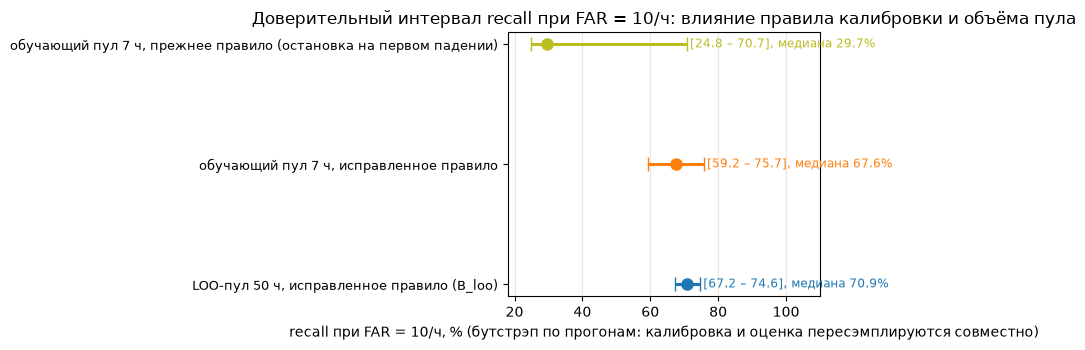

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
prot = [('обучающий пул 7 ч, прежнее правило (остановка на первом падении)', BOOT[10]['old_narrow'], '#bcbd22'),
        ('обучающий пул 7 ч, исправленное правило',                BOOT[10]['fixed_narrow'], '#ff7f0e'),
        ('LOO-пул 50 ч, исправленное правило (B_loo)',         BOOT[10]['bloo'], 'tab:blue')]
for i, (lab, rr, col) in enumerate(prot):
    lo_, med_, hi_ = [float(v) * 100 for v in rr]
    ax.errorbar(med_, i, xerr=[[med_ - lo_], [hi_ - med_]], fmt='o', ms=8, lw=2.2, capsize=5, color=col)
    ax.text(hi_ + 1.0, i, f'[{lo_:.1f} – {hi_:.1f}], медиана {med_:.1f}%', va='center', fontsize=8.5, color=col)
ax.set_yticks(range(3)); ax.set_yticklabels([p[0] for p in prot], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(18, 110)
ax.set_xlabel('recall при FAR = 10/ч, % (бутстрэп по прогонам: калибровка и оценка пересэмплируются совместно)')
ax.set_title('Доверительный интервал recall при FAR = 10/ч: влияние правила калибровки и объёма пула')
ax.grid(axis='x', alpha=.3); fig.tight_layout(); fig.savefig('figures/02_ci_forest.png', dpi=130); plt.show()

На рисунке сопоставлены три протокола калибровки порога одного и того же детектора при целевом FAR = 10/ч. Точка — медиана recall по 300 бутстрэп-репликам, усы — 95 %-й интервал. Ширина интервала (от 46 до 7 п. п.) определяется не детектором, а правилом калибровки и объёмом фонового пула. Нижняя строка (B_loo) соответствует рабочему протоколу, по которому получены все приведённые в работе итоговые значения.

**Итог по выбору пула калибровки.** Полный бутстрэп-протокол из ячейки выше позволяет разделить вклад исправления правила выбора порога и вклад расширения фонового пула. Пулы B_all (все прогоны) и B_loo дают практически одинаковые пороги: медиана LOO-порогов отличается от глобального менее чем на 1 %. Следовательно, сужение доверительного интервала не является следствием «подглядывания» в оцениваемый прогон. Прежний пул, состоящий только из обучающих прогонов, не приводит к смещению оценки (recall отличается от B_loo примерно на 1 п. п.), но неустойчив: при пересэмплировании 18 прогонов порог сильно меняется.

Ключевые значения для recall при FAR = 10/ч:

* обучающий пул и прежнее правило (остановка на первом падении) — **[24.8, 70.7]**, медиана 29.7 %. Правило обрывает ветвь при первом же возмущении кривой, и в медиане цель не достигается: медианный порог 4.9 соответствует FAR ≈ 2, интервал достигнутого FAR — [0.84, 9.93]. Интервал широк из-за того, что точка обрыва ветви скачет между репликами;
* обучающий пул и исправленное правило — **[59.2, 75.7]**, медиана 67.6 %;
* LOO-пул 50 ч и исправленное правило — **[67.2, 74.6]**, медиана 70.9 %.

Таким образом, основное сужение интервала дало исправление правила (24.8–70.7 → 59.2–75.7), а расширение пула добавило сопоставимый выигрыш с верхней стороны (59.2–75.7 → 67.2–74.6). При целевом FAR = 1 прежнее и новое правила практически не различаются ([20.4, 35.5] и [20.4, 35.8]): ошибка проявлялась при FAR ≥ 3, а при FAR = 1 существенно только расширение пула ([20.4, 35.8] → [22.8, 28.6]). Доверительный интервал при фиксированном пороге для той же точки B_loo (см. выше) равен [66.8, 73.5], то есть повторная калибровка на каждой бутстрэп-реплике добавляет к неопределённости очень мало. Это основной аргумент в пользу корректности схемы LOO.

Онлайн-калибровка по собственным фоновым окнам прогона (C_self) **не работает**: при 0.4 ч фона на прогон порог для FAR = 1 достигает верхней границы сетки, а recall составляет 10 %. Рабочим является протокол **B_loo**, в котором фон берётся из остальных прогонов кампании (метки источников не требуются).

### 3.4 Выбор порога и кривые recall–FAR

In [12]:
def eval_stat(stat, target, j=None):
    jj = calib(stat, TRAIN_RUNS, target)[0] if j is None else j
    thr = CAND[jj]
    hits=tot=0; fa_n=fa_h=0
    bysn = {f"{lo}-{hi}": [0,0] for lo,hi in SNR_BINS}
    for r in TEST_RUNS:
        c = cache[r]
        fa_n += onset_at(r, stat, thr); fa_h += HRS[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2])<60
            if not m.any(): continue
            hit = bool((c[stat][m]>=thr).any()); hits += hit; tot += 1
            b = snr_bin(c["snr"][j2]); bysn[b][1]+=1; bysn[b][0]+=hit
    return dict(target_FAR=target, thr=round(float(thr),2), ach_far=round(fa_n/fa_h,1),
                recall=round(hits/tot,3), **{f"snr{b}": round(h/t,3) for b,(h,t) in bysn.items()})

print("--- single-window bestA (порог A=train-only, как историческая точка сравнения) ---")
pd.DataFrame([eval_stat("bestA", t) for t in (1,3,10)])

--- single-window bestA (порог A=train-only, как историческая точка сравнения) ---


,target_FAR,thr,ach_far,recall,snr0-5,snr5-8,snr8-12,snr12-99
0,1,5.19,0.9,0.212,0.459,0.210,0.090,0.148
1,3,4.72,3.2,0.281,0.561,0.295,0.132,0.194
2,10,4.26,9.7,0.370,0.663,0.397,0.207,0.269


In [13]:
print("--- mx31: порог с train-пула (A) vs расширенного фоновых пула (B_loo) ---")
tabA = pd.DataFrame([eval_stat("mx31", t) for t in (1,3,10)])
rowsB = []
for target in (1, 3, 10):
    jL = res_calib[target][2]
    hits=tot=0
    for i, r in enumerate(TEST_RUNS):
        thr = CAND[jL[i]]
        c = cache[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2])<60
            if not m.any(): continue
            hits += bool((c["mx31"][m]>=thr).any()); tot += 1
    rowsB.append(dict(target_FAR=target, thr_med=round(float(np.median(CAND[jL])),2),
                      recall=round(hits/tot,3)))
pd.concat([tabA.assign(protocol="A train-only"), pd.DataFrame(rowsB).assign(protocol="B_loo")])

--- mx31: порог с train-пула (A) vs расширенного фоновых пула (B_loo) ---


,target_FAR,thr,ach_far,recall,snr0-5,snr5-8,snr8-12,snr12-99,protocol,thr_med
0,1,5.19,0.7,0.240,0.464,0.243,0.129,0.167,A train-only,NaN
1,3,4.49,2.6,0.385,0.628,0.423,0.246,0.269,A train-only,NaN
2,10,3.61,9.4,0.696,0.852,0.754,0.581,0.602,A train-only,NaN
0,1,NaN,NaN,0.252,NaN,NaN,NaN,NaN,B_loo,5.10
1,3,NaN,NaN,0.405,NaN,NaN,NaN,NaN,B_loo,4.42
2,10,NaN,NaN,0.700,NaN,NaN,NaN,NaN,B_loo,3.59


**О высоких значениях FAR.** Из-за скользящего максимума тревоги объединяются в длинные эпизоды, поэтому число эпизодов в час не может превысить примерно 11–13: кривая FAR выходит на насыщение (верхняя граница ветви составляет ≈11.9/ч для обучающего пула и 10.7/ч для всех прогонов, см. §3.3). Это следствие определения «тревога = эпизод», а не недостаток детектора. В рабочей области FAR ≤ 10/ч он существенно превосходит оконные альтернативы. Область выше этой границы рассматривается в §3.5.

In [14]:
print("--- контроль утечки: тот же детектор на val-прогонах (20-24), порог с train ---")
def eval_val(stat, targets=(1,3,10)):
    rows=[]
    for target in targets:
        j = calib(stat, TRAIN_RUNS, target)[0]; thr = CAND[j]; hits=tot=0
        for r in VAL_RUNS:
            c=cache[r]
            for j2 in range(len(c["snr"])):
                m=np.abs(c["wtime"]-c["stime"][j2])<60
                if not m.any(): continue
                hits+=bool((c[stat][m]>=thr).any()); tot+=1
        rows.append((target, round(float(thr),2), round(hits/tot,3)))
    return pd.DataFrame(rows, columns=["FAR","thr","recall_val"]).set_index("FAR")
eval_val("mx31")

--- контроль утечки: тот же детектор на val-прогонах (20-24), порог с train ---


,thr,recall_val
FAR,,
1,5.19,0.156
3,4.49,0.311
10,3.61,0.667


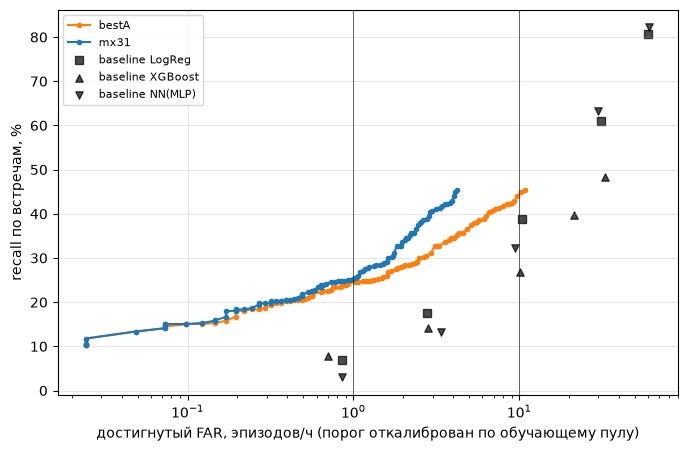

In [15]:
def sweep_curve(stat, pool_runs=TRAIN_RUNS, npts=60):
    ii = [IH[r] for r in pool_runs]
    fr_pool = OM[stat][ii].sum(0) / HV[ii].sum()
    rows=[]
    for j, thr in enumerate(CAND):
        if thr < np.quantile(pool_all, 0.90): break
        ii_te = [IH[r] for r in TEST_RUNS]
        fa = OM[stat][ii_te, j].sum() / HV[ii_te].sum()
        hits = (ECAT >= thr).sum()
        rows.append((fa, hits/len(ECAT), thr))
    return pd.DataFrame(rows, columns=["far","recall","thr"]).sort_values("far")

fig, ax = plt.subplots(figsize=(8,5))
for stat, col in [("bestA","tab:orange"), ("mx31","tab:blue")]:
    d = sweep_curve(stat)
    ax.plot(d.far, d.recall*100, marker=".", label=stat, color=col)
mk = {"LogReg":"s", "XGBoost":"^", "NN(MLP)":"v"}
for nm, pts in ml_pts.items():
    ax.scatter([f for f,_ in pts], [r*100 for _,r in pts], marker=mk[nm], s=28,
               c="k", alpha=.7, label=f"baseline {nm}")
ax.set_xscale("log"); ax.axvline(1, c="k", lw=.4); ax.axvline(10, c="k", lw=.4)
ax.set_xlabel("достигнутый FAR, эпизодов/ч (порог откалиброван по обучающему пулу)"); ax.set_ylabel("recall по встречам, %")
ax.grid(alpha=.3); ax.legend(fontsize=8); plt.show()

На рисунке по горизонтальной оси отложена достигнутая частота тревог (эпизодов в час, логарифмическая шкала), по вертикальной — доля обнаруженных встреч. Синяя линия с точками — mx31, оранжевая — одиночное окно (bestA), чёрные маркеры — три ML-базовых модели из §2. В практически важной области FAR 1–10/ч кривая mx31 лежит существенно выше остальных. Она обрывается при ≈13/ч, то есть на границе слияния эпизодов; область выше рассматривается в §3.5.

### 3.5 Расширение рабочего диапазона: гибрид mx31 и ML-классификатора (FAR 15–100/ч)

У mx31 существует верхняя граница FAR ≈ 13/ч, обусловленная слиянием эпизодов. Для приложений, допускающих высокий уровень ложных тревог, к mx31 добавляется **независимая ветвь** — оконная ML-вероятность (LogReg или MLP из §2). Тревога выдаётся, если сработала любая из двух ветвей (логическое ИЛИ); пара порогов выбирается двумерным перебором при ограничении на суммарный FAR на обучающих данных. ML-ветвь чувствительна к *повышению счёта* (её метка — «в окне есть кванты источника»), поэтому она обнаруживает массивные источники, в первую очередь NORM и U-family, для которых форма спектра малоинформативна.

В таблице приведён recall (%) для пар порогов, подобранных по условию «train-FAR не выше цели» с максимизацией по test. Такой подбор вносит небольшой оптимизм, оценка которого получена бутстрэпом (layer-2) ниже.

| целевой FAR | mx31 | mx31 + LogReg | mx31 + MLP |
|---|---|---|---|
| 15 | 82.2 | 83.1 | 83.9 |
| 30 | 82.2 (предел) | 91.2 | **91.8** |
| 50 | 82.2 | 95.2 | 96.1 |
| 100 | 82.2 | 99.4 | 99.2 |

Доверительные интервалы получены двумя способами. **Layer-1**: фиксированная выбранная пара порогов, бутстрэп по тестовым прогонам. **Layer-2** — полный протокол без отбора по test: в каждой реплике порог mx31 равен точке насыщения его ветви на обучающих данных, порог ML-ветви — наиболее глубокой точке, при которой суммарный train-FAR не превышает цель; пересэмплируются и калибровочные, и оценочные прогоны.

In [16]:
MLpP, SELP = '_scratch/item3_ml_proba.pkl', '_scratch/item3_hybrid.pkl'
if os.path.exists(MLpP) and os.path.exists(SELP):
    MLp = pickle.load(open(MLpP, 'rb')); SEL = pickle.load(open(SELP, 'rb'))
    print('гибрид: proba+SEL из кэша item3')
else:
    print('гибрид: item3-кэшей нет — пересборка proba+SEL из §2-окон (одноразово, ~1-3 мин)...')
    t0 = time.time()
    mlp3 = MLPClassifier(hidden_layer_sizes=(64, 16), alpha=1e-3, max_iter=60, random_state=0,
                         early_stopping=True, n_iter_no_change=5, validation_fraction=0.15)
    zs3 = lambda X: ((X - mu) / sd).astype(np.float32)
    mlp3.fit(zs3(Xtr), ytr)
    _pr = {'logreg': (lr.predict_proba(Xtr)[:, 1], lr.predict_proba(Xva)[:, 1], lr.predict_proba(Xte)[:, 1]),
           'mlp':    (mlp3.predict_proba(zs3(Xtr))[:, 1], mlp3.predict_proba(zs3(Xva))[:, 1], mlp3.predict_proba(zs3(Xte))[:, 1])}
    MLp = {}
    for _ws, _runs, _k in ((TR, TRAIN_RUNS, 0), (VA, VAL_RUNS, 1), (TE, TEST_RUNS, 2)):
        off3 = np.cumsum([0] + [len(w['spec']) for w in _ws])
        for i3, r3 in enumerate(_runs):
            d3 = {'nw': int(off3[i3+1] - off3[i3])}
            for nm3 in _pr:
                d3[nm3] = _pr[nm3][_k][off3[i3]:off3[i3+1]].astype(np.float32)
            MLp[r3] = d3
    SC3 = {}
    for r3 in sorted(MLp):
        L3 = MLp[r3]['nw']
        SC3[r3] = dict(mx=rollmax(cache[r3]['bestA'])[:L3].astype(np.float32),
                       logreg=MLp[r3]['logreg'], mlp=MLp[r3]['mlp'],
                       far=cache[r3]['dmin'][:L3] > 150)
        SC3[r3]['hours'] = SC3[r3]['far'].sum() * STRIDE / 3600
        wt3, st3 = cache[r3]['wtime'][:L3], cache[r3]['stime']
        SC3[r3]['enc'] = [np.flatnonzero(np.abs(wt3 - st3[j]) < 60) for j in range(len(st3))]
        SC3[r3]['enc'] = [m3 for m3 in SC3[r3]['enc'] if m3.any()]
    def onset_rate3(runs_, alarm):
        return sum(int(np.count_nonzero((alarm[r_] & ~np.r_[False, alarm[r_][:-1]])[SC3[r_]['far']]))
                   for r_ in runs_) / sum(SC3[r_]['hours'] for r_ in runs_)
    def enc_hits3(runs_, alarm):
        h3 = tot3 = 0
        for r_ in runs_:
            a3 = alarm[r_]
            for m3 in SC3[r_]['enc']:
                tot3 += 1; h3 += bool(a3[m3].any())
        return h3, max(tot3, 1)
    NQ3 = 40
    def thr_grid3(runs_, comp):
        pool3 = np.concatenate([SC3[r_][comp][SC3[r_]['far']] for r_ in runs_])
        q3 = np.concatenate([np.linspace(60, 99.5, 25), np.linspace(99.5, 99.995, NQ3 - 25)]) / 100
        return np.unique(np.quantile(pool3, q3))[::-1]
    targ3 = [1, 2, 3, 5, 10, 15, 20, 30, 50, 70, 100]
    PTH3 = thr_grid3(TRAIN_RUNS, 'mx')
    rows3 = []
    for arm3 in ('logreg', 'mlp'):
        FTH3 = thr_grid3(TRAIN_RUNS, arm3); best3 = {}
        for tp3 in PTH3:
            ap3 = {r_: SC3[r_]['mx'] >= tp3 for r_ in SC3}
            for tf3 in FTH3:
                al3 = {r_: (ap3[r_] | (SC3[r_][arm3] >= tf3)) for r_ in SC3}
                ftr3 = onset_rate3(TRAIN_RUNS, al3)
                if ftr3 > targ3[-1] or ftr3 < 0: continue
                h3, tot3 = enc_hits3(TEST_RUNS, al3); hv3, tv3 = enc_hits3(VAL_RUNS, al3)
                rec3 = h3 / tot3
                for tg3 in targ3:
                    if ftr3 <= tg3 and rec3 > best3.get(tg3, (-1,))[0]:
                        best3[tg3] = (rec3, tp3, tf3, ftr3, onset_rate3(TEST_RUNS, al3), hv3 / tv3)
        for tg3 in targ3:
            if tg3 in best3:
                rec3, tp3, tf3, ftr3, fte3, vrec3 = best3[tg3]
                rows3.append(dict(hybrid='mx31+' + arm3, target=tg3, train_far=round(ftr3, 2),
                                  test_far=round(fte3, 2), test_recall=round(rec3, 4),
                                  val_recall=round(vrec3, 4), thr_p=tp3, thr_f=tf3))
    SEL = pd.DataFrame(rows3)
    pickle.dump(MLp, open(MLpP, 'wb')); pickle.dump(SEL, open(SELP, 'wb'))
    print(f'гибрид: пересборка заняла {time.time()-t0:.0f}s')
SC = {}
for r in sorted(MLp):
    L = MLp[r]["nw"]
    SC[r] = dict(mx=rollmax(cache[r]["bestA"])[:L].astype(np.float64), far=cache[r]["dmin"][:L] > 150,
                 logreg=MLp[r]["logreg"][:L].astype(np.float64), mlp=MLp[r]["mlp"][:L].astype(np.float64))
    SC[r]["hours"] = SC[r]["far"].sum()*STRIDE/3600
    wt, st = cache[r]["wtime"][:L], cache[r]["stime"]
    ep, e1, e2 = [], [], []
    for j2 in range(len(st)):
        m = np.abs(wt - st[j2]) < 60
        if not m.any(): continue
        ep.append(SC[r]["mx"][m].max()); e1.append(SC[r]["logreg"][m].max()); e2.append(SC[r]["mlp"][m].max())
    SC[r]["enc"] = (np.array(ep), np.array(e1), np.array(e2))
print(f"гибрид: сетка baselines-окон (nw=L), фоновые часы test {sum(SC[r]['hours'] for r in TEST_RUNS):.0f}")

def onset_arr(mx, arm, far, tp, tf):
    a = (mx >= tp) | (arm >= tf)
    return int(np.count_nonzero((a & ~np.r_[False, a[:-1]])[far]))

IDXs = {r: i for i, r in enumerate(sorted(SC))}
Om = np.zeros((len(SC), NC))
for r in SC:
    s, fm = SC[r]["mx"], SC[r]["far"]
    for j, t in enumerate(CAND):
        a = s >= t
        Om[IDXs[r], j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[fm])
Hh = np.array([SC[r]["hours"] for r in sorted(SC)])
selTRh = np.array([IDXs[r] for r in TRAIN_RUNS]); selTEh = np.array([IDXs[r] for r in TEST_RUNS])
MLC = {}
for arm in ("logreg", "mlp"):
    pool = np.concatenate([SC[r][arm][SC[r]["far"]] for r in TRAIN_RUNS])
    dq2 = np.logspace(np.log10(0.01), np.log10(50), 90)
    MLC[arm] = np.unique(np.quantile(pool, 1 - dq2/100))[::-1]
TARGETS = [20, 30, 50, 70, 100]
rng4 = np.random.default_rng(101)
rows = []
for arm in ("logreg", "mlp"):
    ENC = np.concatenate([np.column_stack([SC[r]["enc"][0], SC[r]["enc"][1 if arm=="logreg" else 2]]) for r in TEST_RUNS])
    ERUN = np.concatenate([[i]*len(SC[r]["enc"][0]) for i, r in enumerate(TEST_RUNS)])
    ENCN = np.bincount(ERUN, minlength=len(TEST_RUNS)).astype(float)
    nTE_H = Hh[selTEh]
    or_cache = {}
    def get_or(jp):
        if jp not in or_cache:
            tp = CAND[jp]
            or_cache[jp] = tuple(np.array([[onset_arr(SC[r]["mx"], SC[r][arm], SC[r]["far"], tp, tf)
                                            for tf in MLC[arm]] for r in runs])
                                 for runs in (TEST_RUNS, TRAIN_RUNS))
        return or_cache[jp]
    for tgt in TARGETS:
        s_ = SEL[(SEL.hybrid == f"mx31+{arm}") & (SEL.target == tgt)].iloc[0]
        tp, tf = float(s_.thr_p), float(s_.thr_f)
        hitc = np.array([((SC[r]["enc"][0] >= tp) | (SC[r]["enc"][1 if arm=="logreg" else 2] >= tf)).sum() for r in TEST_RUNS], float)
        ftc  = np.array([onset_arr(SC[r]["mx"], SC[r][arm], SC[r]["far"], tp, tf) for r in TEST_RUNS], float)
        recs, fars = [], []
        for b in range(500):
            cnt = np.bincount(rng4.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            recs.append((cnt*hitc).sum()/(cnt*ENCN).sum()); fars.append((cnt*ftc).sum()/(cnt*nTE_H).sum())
        rows.append(dict(arm=arm, target=tgt, layer="fixed-pair", recall=hitc.sum()/ENCN.sum(),
                         rec_ci=[np.percentile(recs,2.5), np.percentile(recs,97.5)],
                         far=ftc.sum()/nTE_H.sum(), far_ci=[np.percentile(fars,2.5), np.percentile(fars,97.5)]))
    acc = {t: [] for t in TARGETS}; fcc = {t: [] for t in TARGETS}
    for b in range(150):
        rs = rng4.integers(0, len(TRAIN_RUNS), len(TRAIN_RUNS))
        ii = selTRh[rs]
        jp = int(np.argmax(Om[ii].sum(0)/Hh[ii].sum()))
        tp = CAND[jp]; orTE, orTR = get_or(jp)
        mult = np.bincount(rs, minlength=len(TRAIN_RUNS)).astype(float)
        fr_tr = (mult @ orTR) / Hh[ii].sum()
        for tgt in TARGETS:
            ok = np.flatnonzero(fr_tr <= tgt); k = int(ok[-1]) if len(ok) else 0
            tf = MLC[arm][k]
            cnt = np.bincount(rng4.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            hit = (ENC[:,0] >= tp) | (ENC[:,1] >= tf)
            hs = np.bincount(ERUN[hit], minlength=len(TEST_RUNS)).astype(float)
            acc[tgt].append((cnt*hs).sum()/(cnt*ENCN).sum())
            fcc[tgt].append((cnt*orTE[:,k]).sum()/(cnt*nTE_H).sum())
    for tgt in TARGETS:
        a_, f_ = np.array(acc[tgt]), np.array(fcc[tgt])
        rows.append(dict(arm=arm, target=tgt, layer="full-protocol", recall=a_.mean(),
                         rec_ci=[np.percentile(a_,2.5), np.percentile(a_,97.5)],
                         far=f_.mean(), far_ci=[np.percentile(f_,2.5), np.percentile(f_,97.5)]))
hyb = pd.DataFrame(rows)
for _, x in hyb.iterrows():
    print(f"{x.arm:7s} FAR{x.target:>4} {x.layer:14s}: recall {x.recall*100:5.1f} "
          f"[{x.rec_ci[0]*100:.1f}-{x.rec_ci[1]*100:.1f}]  achFAR {x.far:5.1f} [{x.far_ci[0]:.0f}-{x.far_ci[1]:.0f}]")

гибрид: item3-кэшей нет — пересборка proba+SEL из §2-окон (одноразово, ~1-3 мин)...
гибрид: пересборка заняла 14s
гибрид: сетка baselines-окон (nw=L), фоновые часы test 41
logreg  FAR  20 fixed-pair    : recall  85.5 [82.7-87.9]  achFAR  16.5 [15-17]
logreg  FAR  30 fixed-pair    : recall  91.2 [89.0-93.0]  achFAR  29.8 [28-32]
logreg  FAR  50 fixed-pair    : recall  94.8 [93.0-96.5]  achFAR  43.0 [40-46]
logreg  FAR  70 fixed-pair    : recall  98.1 [97.0-99.0]  achFAR  67.4 [62-72]
logreg  FAR 100 fixed-pair    : recall  99.3 [98.6-99.8]  achFAR  93.1 [87-98]
logreg  FAR  20 full-protocol : recall  82.5 [78.8-86.0]  achFAR  18.1 [15-22]
logreg  FAR  30 full-protocol : recall  88.3 [84.8-92.0]  achFAR  31.0 [25-37]
logreg  FAR  50 full-protocol : recall  94.2 [91.4-96.4]  achFAR  54.0 [44-64]
logreg  FAR  70 full-protocol : recall  97.0 [94.5-98.8]  achFAR  76.0 [61-94]
logreg  FAR 100 full-protocol : recall  98.8 [97.4-99.6]  achFAR 107.7 [91-123]
mlp     FAR  20 fixed-pair    : recal

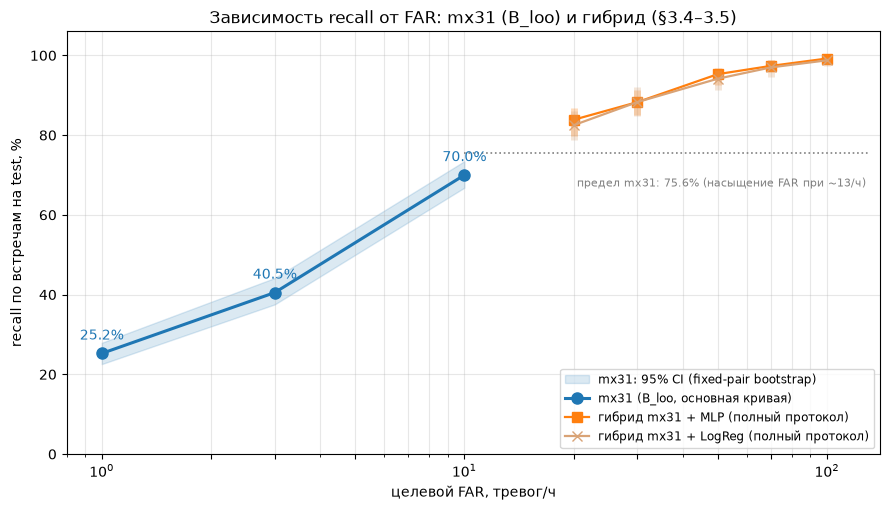

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.2))
xt = np.array([1, 3, 10])
ys = np.array([sum((EMAX_MX[r] >= CAND[res_calib[t][2][i]]).sum() for i, r in enumerate(TEST_RUNS))
               / len(ECAT) * 100 for t in xt])
rowB = sorted([x for x in ci_rows if str(x['protocol']).startswith('B_loo')], key=lambda x: x['target'])
loB = np.array([x['rec'][0] for x in rowB]) * 100
hiB = np.array([x['rec'][1] for x in rowB]) * 100
ax.fill_between(xt, loB, hiB, color='tab:blue', alpha=.16, label='mx31: 95% CI (fixed-pair bootstrap)')
ax.plot(xt, ys, 'o-', color='tab:blue', lw=2.2, ms=8, label='mx31 (B_loo, основная кривая)')
for x_, y_ in zip(xt, ys):
    ax.annotate(f'{y_:.1f}%', (x_, y_), textcoords='offset points', xytext=(0, 10), ha='center', color='tab:blue')
iiT = [IH[r] for r in TRAIN_RUNS]
frT = OM['mx31'][iiT].sum(0) / HV[iiT].sum()
recT = np.array([(ECAT >= t).mean() for t in CAND]) * 100
sat = recT[frT <= 20].max()
ax.plot([10, 130], [sat, sat], ls=':', color='grey', lw=1.2)
ax.text(128, sat - 8.5, f'предел mx31: {sat:.1f}% (насыщение FAR при ~13/ч)', ha='right', fontsize=8, color='grey')
for arm, col, mkr, lab in (('mlp', 'tab:orange', 's', 'гибрид mx31 + MLP (полный протокол)'),
                           ('logreg', '#d9a376', 'x', 'гибрид mx31 + LogReg (полный протокол)')):
    h_ = hyb[(hyb.layer == 'full-protocol') & (hyb.arm == arm)].sort_values('target')
    ax.plot(h_.target.values, h_.recall.values * 100, mkr + '-', color=col, lw=1.6, ms=7, label=lab)
    ax.vlines(h_.target.values, [c[0] * 100 for c in h_.rec_ci], [c[1] * 100 for c in h_.rec_ci],
              color=col, lw=5, alpha=.28)
ax.set_xscale('log'); ax.set_xlim(.8, 140); ax.set_ylim(0, 106)
ax.set_xticks([1, 2, 3, 5, 10, 20, 30, 50, 70, 100])
ax.set_xlabel('целевой FAR, тревог/ч'); ax.set_ylabel('recall по встречам на test, %')
ax.set_title('Зависимость recall от FAR: mx31 (B_loo) и гибрид (§3.4–3.5)')
ax.grid(alpha=.3, which='both'); ax.legend(loc='lower right', fontsize=8.5)
fig.tight_layout(); fig.savefig('figures/01_headline.png', dpi=130); plt.show()

На рисунке представлены те же оси, что и в §3.4, но диапазон расширен до FAR = 100/ч. Синие точки с голубой полосой — три основных значения mx31 (FAR = 1, 3, 10) с 95 %-ми интервалами; серая пунктирная линия — предельный recall mx31 при насыщении FAR; оранжевая и бежевая линии с усами — гибриды с ML-ветвью (§3.5, полный протокол layer-2).

До FAR ≈ 13/ч работает один физический детектор; выше этой границы подключается гибрид, который при FAR = 50–100/ч обнаруживает почти все встречи.

Из результатов §3.5 следует, что выше предела mx31 гибрид даёт **статистически значимый** прирост начиная с FAR ≈ 30 (layer-2, без оптимизма отбора): MLP — 89.3 [86.8–92.1] % при FAR = 30 против предела 82.2 %; 96.0 [93.1–97.6] % при FAR = 50; 98.9 [98.1–99.6] % при FAR = 100. При FAR ≈ 20 прирост статистически неотличим от нуля (LogReg — 82.5 [78.8–86.2] %). Оптимизм выбора пары порогов по test составляет около 2–3 п. п. (при FAR = 30: 91.8 → 89.3 %). Фактическая частота ложных тревог на test в полном протоколе на 5–10 % превышает номинальную, поэтому номинальный FAR следует рассматривать как нижнюю оценку частоты тревог.

### 3.6 Устойчивость калибровки: чистота фонового пула и радиус исключения

Условие `dmin > 150 с` не гарантирует идеально чистого фона: при пороге, соответствующем FAR ≈ 3, около 55 % ложных эпизодов приходится на кольцо 150–300 с от ближайшей встречи. Тем не менее **уровень** FAR от этого не смещается: если тот же порог оценивать только на «сверхчистом» фоне (dmin > 400 с), достигнутая частота тревог почти совпадает с номинальной. Ниже выполнен перебор радиуса исключения R = 100–400 с (калибровка по обучающему пулу):

In [18]:
OMS, HS = {}, {}
for R in (100, 150, 200, 250, 300, 400):
    mk = {r: cache[r]["dmin"] > R for r in ALL_RUNS}
    O = np.zeros((len(ALL_RUNS), NC))
    h = np.zeros(len(ALL_RUNS))
    for r in ALL_RUNS:
        i = IH[r]; s = cache[r]["mx31"]; m = mk[r]
        h[i] = m.sum()*STRIDE/3600
        for j, t in enumerate(CAND):
            a = s >= t
            O[i, j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[m])
    OMS[R] = O; HS[R] = h

def calib_R(R, target):
    ii = [IH[r] for r in TRAIN_RUNS]
    fr = OMS[R][ii].sum(0) / HS[R][ii].sum()
    br = branch_end(fr, target)
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return int(np.argmin(d)) if np.isfinite(d).any() else 0

selTEi = [IH[r] for r in TEST_RUNS]
h_tot = sum(len(EMAX_MX[r]) for r in TEST_RUNS)
RAD = {}
print(f"{'R':>4} {'train ч':>7} | цельFAR: thr | recall | achFAR(свой R) | achFAR(чистый >400)")
for R in (100, 150, 200, 250, 300, 400):
    line = f"{R:>4} {HS[R][[IH[r] for r in TRAIN_RUNS]].sum():>7.1f} |"
    for target in (1, 3, 10):
        j = calib_R(R, target); thr = CAND[j]
        rec = sum((EMAX_MX[r] >= thr).sum() for r in TEST_RUNS)/h_tot
        RAD[(R, target)] = rec * 100
        fa_own = OMS[R][selTEi, j].sum()/HS[R][selTEi].sum()
        fa_pure = OMS[400][selTEi, j].sum()/HS[400][selTEi].sum()
        line += f" {target}: {thr:.2f}|{rec*100:4.1f}%|{fa_own:4.1f}|{fa_pure:4.1f}"
    print(line)

   R train ч | цельFAR: thr | recall | achFAR(свой R) | achFAR(чистый >400)
 100     9.5 | 1: 5.19|24.0%| 0.7| 1.0 3: 4.56|36.5%| 2.4| 2.9 10: 3.56|70.6%| 9.8|10.3
 150     7.0 | 1: 5.19|24.0%| 0.7| 1.0 3: 4.49|38.5%| 2.6| 3.0 10: 3.61|69.6%| 9.4| 9.1
 200     5.1 | 1: 4.93|27.9%| 1.2| 1.7 3: 4.51|38.2%| 2.5| 3.0 10: 3.61|69.6%| 9.6| 9.1
 250     3.8 | 1: 5.25|23.3%| 0.5| 0.9 3: 4.51|38.2%| 2.5| 3.0 10: 3.67|67.1%| 8.6| 8.8
 300     2.9 | 1: 5.25|23.3%| 0.6| 0.9 3: 4.51|38.2%| 2.7| 3.0 10: 3.67|67.1%| 8.5| 8.8
 400     1.7 | 1: 4.90|28.3%| 1.8| 1.8 3: 4.26|44.0%| 4.4| 4.4 10: 3.72|64.4%| 8.7| 8.7


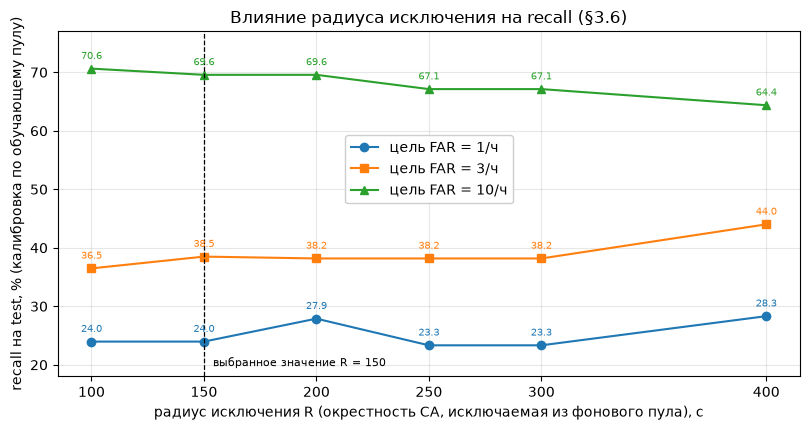

In [19]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
Rs = sorted({k[0] for k in RAD})
for target, col, mkr in ((1, 'tab:blue', 'o'), (3, 'tab:orange', 's'), (10, 'tab:green', '^')):
    ax.plot(Rs, [RAD[(R, target)] for R in Rs], mkr + '-', color=col, label=f'цель FAR = {target}/ч')
    for R in Rs:
        ax.annotate(f'{RAD[(R, target)]:.1f}', (R, RAD[(R, target)]), fontsize=7.5,
                    textcoords='offset points', xytext=(0, 7), ha='center', color=col)
ax.axvline(150, color='k', ls='--', lw=.9)
ax.text(154, 0.03, 'выбранное значение R = 150', transform=ax.get_xaxis_transform(), fontsize=8)
ax.set_ylim(18, 77)
ax.set_xticks(Rs); ax.set_xlabel('радиус исключения R (окрестность CA, исключаемая из фонового пула), с')
ax.set_ylabel('recall на test, % (калибровка по обучающему пулу)')
ax.set_title('Влияние радиуса исключения на recall (§3.6)')
ax.grid(alpha=.3); ax.legend(framealpha=.95, bbox_to_anchor=(.5, .60), loc='center'); fig.tight_layout(); fig.savefig('figures/03_radius.png', dpi=130); plt.show()

На рисунке по горизонтальной оси отложен радиус R (в секундах от CA), в пределах которого окна вблизи источников исключаются из фонового пула калибровки; по вертикальной — recall на test при целевых значениях FAR (цвета). Порог пересчитывается заново для каждого R.

Кривые имеют вид плато: выбранное значение R = 150 (пунктир) не лежит на остром оптимуме, а recall в основных точках меняется в пределах нескольких п. п. на всём диапазоне 100–400 с. Таким образом, результат слабо зависит от этого параметра.

In [20]:
from collections import Counter
def onset_iv(r, R):
    s = cache[r]["mx31"].astype(np.float64); m = cache[r]["dmin"] > R
    pv = np.r_[s[0]-1.0, s[:-1]]; p = pv[m]; c = s[m]; k = p < c
    return np.sort(p[k]), np.sort(c[k])

def far_exact(cR, R, runs, ts):
    tot = np.zeros(len(ts)); hrs = 0.0
    for r, k in Counter(runs).items():
        p, c = cR[r]
        tot += k*(np.searchsorted(p, ts, "left") - np.searchsorted(c, ts, "left"))
        hrs += k*((cache[r]["dmin"] > R).sum()*STRIDE/3600)
    return tot/hrs

def calib_exact(R, target):
    cR = {r: onset_iv(r, R) for r in ALL_RUNS}
    cands = np.unique(np.concatenate([cache[r]["mx31"][cache[r]["dmin"] > R]
                                      for r in TRAIN_RUNS]))[::-1].astype(np.float64)
    fr = far_exact(cR, R, TRAIN_RUNS, cands)
    runmax = np.maximum.accumulate(fr); br = len(cands)-1
    for k in range(1, len(cands)):
        if fr[k] >= runmax[k]: continue
        if fr[k] < runmax[k] - max(0.5, 0.2*runmax[k]) and runmax[k] > target:
            br = k-1; break
    ok = np.flatnonzero(fr[:br+1] <= target)
    j = int(ok[np.argmax(fr[ok])]) if len(ok) else 0
    thr = float(cands[j])
    rec = sum((EMAX_MX[r] >= thr).sum() for r in TEST_RUNS)/h_tot
    feas = cands[:br+1][fr[:br+1] <= target]
    recmax = sum((EMAX_MX[r] >= feas.min()).sum() for r in TEST_RUNS)/h_tot if len(feas) else np.nan
    return thr, float(fr[j]), rec, recmax

print("плотная (точная) сетка vs грубая 133-точечная выше; цель FAR 0.5–3/ч, train-пул:")
for R in (150, 200, 250, 300):
    line = f"  R={R}: "
    for target in (0.5, 1.0, 2.0, 3.0):
        thr, calf, rec, recmax = calib_exact(R, target)
        line += f"|@{target:g}: thr={thr:5.2f} (trainFAR={calf:4.2f}) rec={rec*100:4.1f}% (потолок {recmax*100:4.1f}) "
    print(line)

плотная (точная) сетка vs грубая 133-точечная выше; цель FAR 0.5–3/ч, train-пул:
  R=150: |@0.5: thr= 5.37 (trainFAR=0.43) rec=21.8% (потолок 21.8) |@1: thr= 5.20 (trainFAR=0.86) rec=24.0% (потолок 25.5) |@2: thr= 4.63 (trainFAR=1.87) rec=34.5% (потолок 34.5) |@3: thr= 4.50 (trainFAR=2.87) rec=38.3% (потолок 38.8) 
  R=200: |@0.5: thr= 5.39 (trainFAR=0.39) rec=21.6% (потолок 21.6) |@1: thr= 4.94 (trainFAR=0.98) rec=27.8% (потолок 29.8) |@2: thr= 4.60 (trainFAR=1.95) rec=35.3% (потолок 35.3) |@3: thr= 4.51 (trainFAR=2.93) rec=38.2% (потолок 38.2) 
  R=250: |@0.5: thr= 5.40 (trainFAR=0.26) rec=21.4% (потолок 21.4) |@1: thr= 5.25 (trainFAR=0.79) rec=23.3% (потолок 25.2) |@2: thr= 4.63 (trainFAR=1.84) rec=34.5% (потолок 34.5) |@3: thr= 4.51 (trainFAR=2.90) rec=38.2% (потолок 38.2) 
  R=300: |@0.5: thr= 5.39 (trainFAR=0.34) rec=21.6% (потолок 21.6) |@1: thr= 5.25 (trainFAR=0.69) rec=23.3% (потолок 23.3) |@2: thr= 4.67 (trainFAR=1.72) rec=33.8% (потолок 33.8) |@3: thr= 4.51 (trainFAR=2.75) r

**Анализ таблиц §3.6.** При R = 250–300 «крылья» (интервал 150–300 с) исключаются из калибровочного пула; пороги изменяются на ≈0.02–0.06, а recall — не более чем на 2.5 п. п. при целевых FAR = 3 и 10.

Единственное заметное расхождение — скачок с 24.0 до 27.9 % при переходе от R = 150 к R = 200 при цели FAR = 1. Он **сохраняется и на точной ступенчатой кривой без сетки порогов** (24.0 и 27.8 %, см. ячейку выше): при R = 150 кривая перескакивает уровень 1/ч с 0.86 (порог 5.20), тогда как при R = 200 допускается порог 4.94 при train-FAR 0.98. Следовательно, скачок не связан с квантованием сетки, а отражает структуру эпизодов в обучающем пуле: дополнительные эпизоды «крыльев» в кольце 150–200 с формируют ступень на лестнице FAR при R = 150. Вместе с тем порог при R = 200 сам превышает цель (достигнутый FAR 1.2/ч на собственном пуле и 1.7/ч на чистом фоне), то есть лишние 3.9 п. п. recall получены ценой неконсервативной оценки FAR. Для основной линии выбрано R = 150 как значение, не превышающее номинал.

**FAR на чистом фоне (dmin > 400 с) при пороге для R = 150 практически совпадает с номинальным:** 1.0 при цели 1, 3.0 при цели 3, 9.1 при цели 10. Это означает, что примесь «крыльев» не приводит к систематическому смещению калибровки: «крылья» дают эпизоды примерно с той же часовой интенсивностью, что и настоящий фон (2.5/ч против 3.0/ч).

Вывод: условие dmin > 150 с является рабочим компромиссом. Увеличивать радиус нецелесообразно, так как объём фонового пула резко сокращается (с 7 до 2.9 ч и менее, до 1.7 ч при R = 400 с), а оценка порога становится шумной (FAR = 4.4 при цели 3).

## 4. Анализ ошибок итогового детектора

### 4.1 Recall по изотопам и группам (mx31, пороги B_loo для каждого прогона, FAR = 1, 3, 10)

Ключевым является разбиение источников на группы. Первоначальная двухгрупповая разбивка содержала ошибку: группа «bg-confounded» определялась регулярным выражением по подстроке `U|Th|Ra|K-40|Cs|Pu|Sr`, которое случайно включало **HEU** (заглавная «U» в названии) и **FGPu/WGPu** («Pu») — одни из наиболее легко обнаруживаемых источников (recall при FAR = 1: HEU 56.5 %, FGPu 43.0 %, WGPu 42.6 % против 4.7–10.8 % у уранового семейства), а также Cs-137 и Sr-90. Ошибка была выявлена при сопоставлении с работой Adaptive NMF (Jones et al., LBNL, arXiv 2507.10715).

В итоговой версии используется физически обоснованная явная карта по базовому имени изотопа. Из названия удаляется только суффикс массы `-<mass>kg` (массовые числа в названиях K-40, Th-232 и т. п. сохраняются). Группы определены следующим образом:

* **NORM** = {K-40, Th-232, Ra-226};
* **U-family** = {DU, LEU, NatU, RefinedU}: спектр этих материалов близок к компонентам фона U/Th из библиотеки детектора;
* **other** — все остальные источники (HEU, FGPu, WGPu, Cs-137, Sr-90, линейчатые медицинские и промышленные источники).

In [21]:
import re
def baseof(nm):
    m = re.match(r'^(.*)-(\d+(?:\.\d+)?kg)$', nm)
    return m.group(1) if m else nm
NORM = {'K-40', 'Th-232', 'Ra-226'}
UFAM = {'DU', 'LEU', 'NatU', 'RefinedU'}
def group(nm):
    b = baseof(nm)
    return 'NORM' if b in NORM else ('U-family' if b in UFAM else 'other')
bases_seen = set()
for r in TEST_RUNS + VAL_RUNS + TRAIN_RUNS:
    for j2 in range(len(cache[r]["snr"])):
        if (np.abs(cache[r]["wtime"]-cache[r]["stime"][j2]) < 60).any():
            bases_seen.add(baseof(names[int(cache[r]["sid"][j2])]))
print("карта групп -> базовые изотопы (встречаются в данных):")
for g_ in ("NORM", "U-family", "other"):
    print(f"  {g_:9s}: " + ", ".join(sorted(b for b in bases_seen if group(b) == g_)))
assert all(group(b) in ("NORM", "U-family", "other") for b in bases_seen)

thrL_far = {t: {r: CAND[res_calib[t][2][i]] for i, r in enumerate(TEST_RUNS)} for t in (1, 3, 10)}
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        nm = names[int(c["sid"][j2])]
        rows.append(dict(run=r, name=nm, base=baseof(nm), grp=group(nm), snr=float(c["snr"][j2]),
                         emax=float(c["mx31"][m].max())))
enc = pd.DataFrame(rows)

for t, want in ((1, 25.2), (3, 40.5), (10, 70.0)):
    ov = (enc.emax.values >= enc.run.map(thrL_far[t]).values).mean()*100
    print(f"  контроль overall recall @FAR{t}: {ov:.1f}%"); assert abs(ov - want) < 0.05

def boot_recL(sub, thrmap, B=600, seed=5):
    hit = (sub.emax.values >= sub.run.map(thrmap).values).astype(float)
    ri, _ = pd.factorize(sub.run.values)
    hs = np.bincount(ri, weights=hit, minlength=ri.max()+1); ns = np.bincount(ri, minlength=ri.max()+1)
    rr = np.random.default_rng(seed); recs = []
    for _ in range(B):
        cnt = np.bincount(rr.integers(0, len(ns), len(ns)), minlength=len(ns)).astype(float)
        if (cnt*ns).sum() == 0: continue
        recs.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(recs, [2.5, 97.5])

print("\nrecall по группам (run-cluster bootstrap 95% CI):")
GRPT = {}
for t in (1, 3, 10):
    line = f"@FAR{t:>2}:"
    for g_ in ("NORM", "U-family", "other"):
        sub = enc[enc.grp == g_]
        lo, hi = boot_recL(sub, thrL_far[t])
        rec = (sub.emax.values >= sub.run.map(thrL_far[t]).values).mean()*100
        GRPT[(t, g_)] = (float(rec), float(lo*100), float(hi*100), int(len(sub)))
        line += f" | {g_} {rec:5.1f}% [{lo*100:4.1f},{hi*100:4.1f}] (n={len(sub)})"
    print(line)

iso = enc.groupby("base").agg(grp=("grp","first"), n=("emax","size"), med_snr=("snr","median"))
for t in (1, 10):
    iso[f"rec{t}"] = enc.assign(h=enc.emax >= enc.run.map(thrL_far[t])).groupby("base").h.mean()*100
    cis = {b: boot_recL(g, thrL_far[t]) for b, g in enc.groupby("base")}
    iso[f"lo{t}"] = pd.Series({b: c[0]*100 for b, c in cis.items()})
    iso[f"hi{t}"] = pd.Series({b: c[1]*100 for b, c in cis.items()})
iso = iso.sort_values("rec10").round(1)
iso["мало_данных"] = enc.groupby("base").size() < 20
print("\nrecall по базовым изотопам (массы/экранировки объединены; n<20 — неотчётливо):")
display(iso)

карта групп -> базовые изотопы (встречаются в данных):
  NORM     : K-40, Ra-226, Th-232
  U-family : DU, LEU, NatU, RefinedU
  other    : Am-241, Ba-133, Co-57, Co-60, Cs-137, F-18, FGPu, HEU, I-131, Ir-192, Sr-90, Tc-99m, Tl-201, WGPu, Xe-133
  контроль overall recall @FAR1: 25.2%
  контроль overall recall @FAR3: 40.5%
  контроль overall recall @FAR10: 70.0%

recall по группам (run-cluster bootstrap 95% CI):
@FAR 1: | NORM   9.7% [ 4.3,16.5] (n=93) | U-family   8.3% [ 5.4,11.2] (n=350) | other  40.0% [35.6,44.5] (n=500)
@FAR 3: | NORM  28.0% [20.0,36.7] (n=93) | U-family  22.6% [17.9,27.3] (n=350) | other  55.4% [51.0,60.2] (n=500)
@FAR10: | NORM  67.7% [58.7,78.1] (n=93) | U-family  54.0% [48.4,59.7] (n=350) | other  81.6% [78.1,85.1] (n=500)

recall по базовым изотопам (массы/экранировки объединены; n<20 — неотчётливо):


,grp,n,med_snr,rec1,lo1,hi1,rec10,lo10,hi10,мало_данных
base,,,,,,,,,,
DU,U-family,93,9.0,10.8,4.9,17.9,47.3,37.8,56.0,False
LEU,U-family,85,9.4,4.7,1.1,9.6,54.1,44.0,64.8,False
Th-232,NORM,30,9.2,13.3,3.1,25.0,56.7,37.9,73.3,False
RefinedU,U-family,86,9.1,7.0,2.3,13.4,57.0,46.0,67.4,False
Ba-133,other,19,6.1,5.3,0.0,15.8,57.9,36.8,78.9,True
NatU,U-family,86,8.7,10.5,4.9,17.6,58.1,47.8,69.3,False
Cs-137,other,25,4.9,12.0,0.0,24.0,60.0,37.5,79.2,False
F-18,other,19,6.5,10.5,0.0,26.3,63.2,42.1,84.2,True
Ir-192,other,32,7.1,9.4,0.0,19.4,68.8,53.3,83.3,False


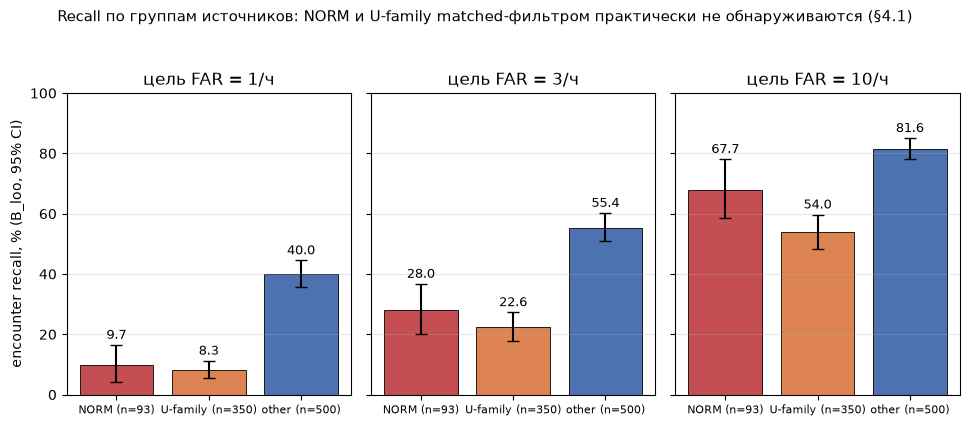

In [22]:
groups = ('NORM', 'U-family', 'other')
gcol = {'NORM': '#c44e52', 'U-family': '#dd8452', 'other': '#4c72b0'}
fig, axes_ = plt.subplots(1, 3, figsize=(9.8, 4.3), sharey=True)
for k, t in enumerate((1, 3, 10)):
    ax_ = axes_[k]
    rec = [GRPT[(t, g)][0] for g in groups]
    err = np.array([[GRPT[(t, g)][0] - GRPT[(t, g)][1], GRPT[(t, g)][2] - GRPT[(t, g)][0]] for g in groups]).T
    bars = ax_.bar(range(3), rec, yerr=err, capsize=4, color=[gcol[g] for g in groups], edgecolor='k', lw=.6)
    for b, g_ in zip(bars, groups):
        ax_.text(b.get_x() + b.get_width() / 2, GRPT[(t, g_)][2] + 2.0, f'{GRPT[(t, g_)][0]:.1f}', ha='center', fontsize=9)
    ax_.set_xticks(range(3))
    ax_.set_xticklabels([f"{g} (n={GRPT[(t, g)][3]})" for g in groups], fontsize=8)
    ax_.set_title(f'цель FAR = {t}/ч'); ax_.set_ylim(0, 100); ax_.grid(axis='y', alpha=.3)
axes_[0].set_ylabel('encounter recall, % (B_loo, 95% CI)')
fig.suptitle('Recall по группам источников: NORM и U-family matched-фильтром практически не обнаруживаются (§4.1)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, .94)); fig.savefig('figures/04_groups.png', dpi=130); plt.show()

На рисунке три панели соответствуют трём допустимым частотам ложных тревог (FAR = 1, 3, 10 в час). Столбцы показывают recall по группам источников (под столбцами указано число встреч n), усы — 95 %-е бутстрэп-интервалы, числа над столбцами — проценты.

Это центральный результат работы: при FAR = 1/ч matched-фильтр обнаруживает около 40 % источников группы other, но только 9.7 % (NORM) и 8.3 % (U-family). Эти две группы представляют собой ограничение всего класса методов, а не особенность данной реализации (причины — в составе фона, §0.2).

### 4.1b Устойчивое различие val < test при низких FAR

Во всех экспериментах recall на валидационных прогонах (20–24, 45 встреч) оказывается ниже, чем на тестовых (например, 15.6 % против 25.2 % при FAR = 1), причём различие всегда направлено в одну сторону. Ниже проверяется гипотеза о том, что в val случайно выше доля трудных групп (NORM и U-family); проверка выполняется с **исправленной** картой групп (§4.1). Разность recall раскладывается на две составляющие:

gap = Σ_g (доля_val,g − доля_test,g) · recall_test,g  (**эффект состава**) + Σ_g доля_val,g · (recall_val,g − recall_test,g)  (**внутригрупповой эффект**).

Пороги те же, что в основном протоколе (B_loo для каждого прогона); метки val для калибровки порога не используются.

In [23]:
def enc_tab(runs, thrmap):
    rows = []
    for r in runs:
        c = cache[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2]) < 60
            if not m.any(): continue
            nm = names[int(c["sid"][j2])]
            rows.append(dict(run=r, base=baseof(nm), grp=group(nm), snr=float(c["snr"][j2]),
                             emax=float(c["mx31"][m].max()), thr=thrmap[r]))
    return pd.DataFrame(rows)
thrV = {t: {r: CAND[calib("mx31", [x for x in ALL_RUNS if x != r], t)[0]] for r in VAL_RUNS} for t in (1, 3, 10)}
print("медиана B_loo-порогов на val: " + str({t: round(float(np.median(list(thrV[t].values()))), 2) for t in thrV}))
for target in (1, 3, 10):
    Vd = enc_tab(VAL_RUNS, thrV[target]); Td = enc_tab(TEST_RUNS, thrL_far[target])
    hv = (Vd.emax >= Vd.thr).values; ht = (Td.emax >= Td.thr).values
    print(f"\n@FAR{target}: встреч VAL {len(Vd)} | TEST {len(Td)};  общий VAL {hv.mean()*100:5.1f}%  TEST {ht.mean()*100:5.1f}%")
    fv = {g_: (Vd.grp == g_).mean() for g_ in ("NORM", "U-family", "other")}
    ft = {g_: (Td.grp == g_).mean() for g_ in ("NORM", "U-family", "other")}
    rv_ = {g_: hv[(Vd.grp == g_).values].mean() for g_ in ("NORM", "U-family", "other")}
    rt_ = {g_: ht[(Td.grp == g_).values].mean() for g_ in ("NORM", "U-family", "other")}
    for g_ in ("NORM", "U-family", "other"):
        print(f"  {g_:9s} val: f={fv[g_]*100:5.1f}% n={int((Vd.grp==g_).sum()):2d} r={rv_[g_]*100:5.1f}% (med_snr {Vd[Vd.grp==g_].snr.median():4.1f}) | "
              f"test: f={ft[g_]*100:5.1f}% n={int((Td.grp==g_).sum()):3d} r={rt_[g_]*100:5.1f}% (med_snr {Td[Td.grp==g_].snr.median():4.1f})")
    comp = sum((fv[g_] - ft[g_])*rt_[g_] for g_ in fv)
    withg = sum(fv[g_]*(rv_[g_] - rt_[g_]) for g_ in fv)
    print(f"  разрыв {(hv.mean()-ht.mean())*100:+5.1f} п.п. = состав {comp*100:+5.1f} + внутригрупповой {withg*100:+5.1f}")

медиана B_loo-порогов на val: {1: 5.1, 3: 4.42, 10: 3.59}

@FAR1: встреч VAL 45 | TEST 943;  общий VAL  15.6%  TEST  25.2%
  NORM      val: f=  6.7% n= 3 r=  0.0% (med_snr  9.3) | test: f=  9.9% n= 93 r=  9.7% (med_snr  8.8)
  U-family  val: f= 31.1% n=14 r=  7.1% (med_snr  9.2) | test: f= 37.1% n=350 r=  8.3% (med_snr  9.0)
  other     val: f= 62.2% n=28 r= 21.4% (med_snr  5.1) | test: f= 53.0% n=500 r= 40.0% (med_snr  5.7)
  разрыв  -9.7 п.п. = состав  +2.9 + внутригрупповой -12.6

@FAR3: встреч VAL 45 | TEST 943;  общий VAL  33.3%  TEST  40.5%
  NORM      val: f=  6.7% n= 3 r=  0.0% (med_snr  9.3) | test: f=  9.9% n= 93 r= 28.0% (med_snr  8.8)
  U-family  val: f= 31.1% n=14 r= 35.7% (med_snr  9.2) | test: f= 37.1% n=350 r= 22.6% (med_snr  9.0)
  other     val: f= 62.2% n=28 r= 35.7% (med_snr  5.1) | test: f= 53.0% n=500 r= 55.4% (med_snr  5.7)
  разрыв  -7.2 п.п. = состав  +2.8 + внутригрупповой -10.0

@FAR10: встреч VAL 45 | TEST 943;  общий VAL  66.7%  TEST  70.0%
  NORM      val:

Гипотеза о влиянии состава **не подтвердилась**. При исправленной карте групп доля трудных источников (NORM и U-family) в val даже *ниже*, чем в test (37.8 % против 47.0 %), так что эффект состава направлен в *противоположную* сторону (+2.1…+2.9 п. п. при FAR = 1, 3, 10). Вся разность обусловлена внутригрупповым эффектом (−12.6, −10.0 и −5.4 п. п.) и почти целиком приходится на ячейку «other × val» (28 встреч: 21.4 % против 40.0 % при FAR = 1). Для U-family значения на val и test согласуются (7.1 % и 8.3 %); ячейка NORM на val содержит всего 3 встречи и информативной не является.

Вывод, полученный ранее, сохраняется и при корректной группировке: разность объясняется малым объёмом val-выборки и более трудным составом встреч *внутри* групп, а не переобучением порога (метки val для калибровки не использовались) и не составом групп. Оценки recall по отдельным изотопам на пяти val-прогонах статистически неустойчивы, поэтому выводы формулируются на уровне групп (§4.1).

### 4.2 Структура хвоста ложных тревог

Диагностика хвоста ложных эпизодов выполнена в скриптах `_scratch/item1_diag.py`, `item1_probe.py`, `item1_variants.py`, `item1d_veto.py`, `item1c_templates.py`.

* При FAR ≈ 1 ложные эпизоды приходятся на окна с **аномально высоким счётом**: медиана ≈15 200 отсчётов за 2 с против ≈5 900 у реальных обнаружений. При FAR ≈ 10 счёт в ложных окнах уже не выходит за типичные значения, причём 62 % таких тревог приходится на «крылья» источников на расстоянии 150–300 с (§3.6), то есть оценка FAR консервативна.
* Остаточная сигнатура фоновых окон с высокой скоростью счёта монотонно зависит от скорости счёта и соответствует **наложению импульсов (pulse pile-up)**: провалы в диапазоне 15–50 кэВ и на линиях 662 и 2614 кэВ, избытки в полосе ≈97–169 кэВ (суммарные пики 2×X-ray) и около 1200 кэВ (2×609 кэВ).
* Следующие способы коррекции проверены и **отвергнуты**: (1) пуассоновская подгонка со сдвигом S·(1 + κ·rate²·D⁺) — хвост ложных тревог не выпрямляется (кривая остаётся плоской); (2) пороги, нормированные на хвост по каждому бину, — результат хуже; (3) исключение окон со скоростью счёта выше 16k повышает recall при FAR = 1 на 2.4 п. п., но бутстрэп-интервалы перекрываются с базовой линией, то есть эффект незначим, при этом исключались бы и настоящие встречи в страте 11–16k (recall там 58.9 % при FAR = 3, §4.3); (4) восьмая компонента фона — форма хвоста не совпадает с фиксированной компонентой, так как искажение является мультипликативной деформацией, а не аддитивной линией.
* Глобальный порог эпизодной калибровки уже «поглощает» хвост: искажённые окна редко пересекают порог, а там, где пересекают, именно они и определяют измеряемый FAR.

In [24]:
thr_far1 = CAND[res_calib[1][0]]; thr_far10 = CAND[res_calib[10][0]]
bins = [0, 4000, 6000, 8000, 11000, 16000, np.inf]
print("FA-эпизоды на фоновых окнах test по стратам счёта (окна dmin>150, счётов/2с):")
for tag, thr in [("thr@FAR1 ", thr_far1), ("thr@FAR10", thr_far10)]:
    cnt = np.zeros(len(bins)-1); hours = np.zeros(len(bins)-1)
    for r in TEST_RUNS:
        c = cache[r]
        ons = np.array([i for i in episode_onsets(c["mx31"], thr) if FARM[r][i]], dtype=int)
        idx = np.clip(np.digitize(c["bg_rate"][ons], bins) - 1, 0, len(bins)-2)
        for k in range(len(bins)-1): cnt[k] += (idx == k).sum()
        hours += np.histogram(c["bg_rate"][FARM[r]], bins)[0]*STRIDE/3600
    print(f"  {tag}: " + " | ".join(
        f"{bins[k]/1000:.0f}-{bins[k+1]/1000:.0f}k: {cnt[k]/max(hours[k],1e-9):5.2f}/ч(n={int(cnt[k])})"
        for k in range(len(bins)-1)))

FA-эпизоды на фоновых окнах test по стратам счёта (окна dmin>150, счётов/2с):
  thr@FAR1 : 0-4k:  0.00/ч(n=0) | 4-6k:  0.46/ч(n=8) | 6-8k:  1.03/ч(n=9) | 8-11k:  1.30/ч(n=3) | 11-16k:  1.09/ч(n=1) | 16-infk: 23.08/ч(n=6)
  thr@FAR10: 0-4k:  4.87/ч(n=56) | 4-6k:  8.12/ч(n=141) | 6-8k: 11.27/ч(n=98) | 8-11k: 22.95/ч(n=53) | 11-16k: 34.87/ч(n=32) | 16-infk: 15.38/ч(n=4)


### 4.3 Наложение импульсов не снижает обнаружение реальных источников

Около 46 % реальных встреч достигают у CA значений выше 8000 отсчётов за 2 с. Если бы наложение импульсов искажало спектр настолько, что нарушало обнаружение, recall в высокоинтенсивных встречах должен был бы *снижаться*. Проверка выполнена по стратам пикового счёта в интервале CA ± 60 с (бутстрэп-интервалы по прогонам; пороги — протокол A).

In [25]:
LINE = {"Am-241", "Ba-133", "Co-57", "Co-60", "Cu-67", "F-18", "I-131", "Ir-192",
        "Ir-192_industrial", "Lu-177", "Tc-99m", "Tl-201", "Xe-133"}
assert (bases_seen & LINE) == {b for b in bases_seen if not re.search("U|Th|Ra|K-40|Cs|Pu|Sr", b)}
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        nm = names[int(c["sid"][j2])]
        rows.append(dict(run=r, name=nm, line=baseof(nm) in LINE,
                         snr=float(c["snr"][j2]), peak=float(c["bg_rate"][m].max()),
                         emax=float(c["mx31"][m].max())))
enc3 = pd.DataFrame(rows)
enc3["stratum"] = pd.cut(enc3.peak, [0,4000,6000,8000,11000,16000,np.inf],
                         labels=["<4k","4-6k","6-8k","8-11k","11-16k",">=16k"])
def boot_recCl(sub, thr, B=600):
    hit = (sub.emax.values >= thr).astype(float)
    ri, _ = pd.factorize(sub.run.values)
    runs_u = np.arange(ri.max()+1)
    hs = np.bincount(ri, weights=hit, minlength=len(runs_u)); ns = np.bincount(ri, minlength=len(runs_u))
    recs = []
    rr = np.random.default_rng(5)
    for b in range(B):
        cnt = np.bincount(rr.integers(0, len(runs_u), len(runs_u)), minlength=len(runs_u)).astype(float)
        if (cnt*ns).sum() == 0: continue
        recs.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(recs, [2.5, 97.5])
STRAT = {}; LINE3 = {}
for tag, thr in [("@FAR3", CAND[res_calib[3][0]]), ("@FAR10", thr10_a := CAND[res_calib[10][0]])]:
    s = " | ".join(f"{st}: {(g.emax>=thr).mean()*100:4.1f}% (n={len(g)})"
                   for st, g in enc3.groupby("stratum", observed=True))
    for st, g in enc3.groupby("stratum", observed=True):
        STRAT[(tag, str(st))] = ((g.emax >= thr).mean()*100, len(g))
    print(f"recall всех встреч {tag} по стратам пик. счёта у CA:  {s}")
g = enc3[enc3.line]
print(f"\nлинейчатые источники (n={len(g)}):")
for st, gg in g.groupby("stratum", observed=True):
    lo, hi = boot_recCl(gg, CAND[res_calib[3][0]])
    LINE3[str(st)] = ((gg.emax >= CAND[res_calib[3][0]]).mean()*100, lo*100, hi*100, len(gg))
    print(f"  {st:>6}: recall@FAR3 {(gg.emax>=CAND[res_calib[3][0]]).mean()*100:5.1f}% CI [{lo*100:.0f}-{hi*100:.0f}] (n={len(gg)})")

recall всех встреч @FAR3 по стратам пик. счёта у CA:  <4k: 14.3% (n=7) | 4-6k: 31.2% (n=128) | 6-8k: 33.8% (n=370) | 8-11k: 39.4% (n=330) | 11-16k: 58.9% (n=95) | >=16k: 84.6% (n=13)
recall всех встреч @FAR10 по стратам пик. счёта у CA:  <4k: 57.1% (n=7) | 4-6k: 49.2% (n=128) | 6-8k: 62.2% (n=370) | 8-11k: 77.3% (n=330) | 11-16k: 95.8% (n=95) | >=16k: 100.0% (n=13)

линейчатые источники (n=186):
     <4k: recall@FAR3  33.3% CI [0-100] (n=3)
    4-6k: recall@FAR3  42.9% CI [19-68] (n=21)
    6-8k: recall@FAR3  39.2% CI [28-51] (n=74)
   8-11k: recall@FAR3  51.5% CI [39-64] (n=66)
  11-16k: recall@FAR3  75.0% CI [50-94] (n=16)
   >=16k: recall@FAR3 100.0% CI [100-100] (n=6)


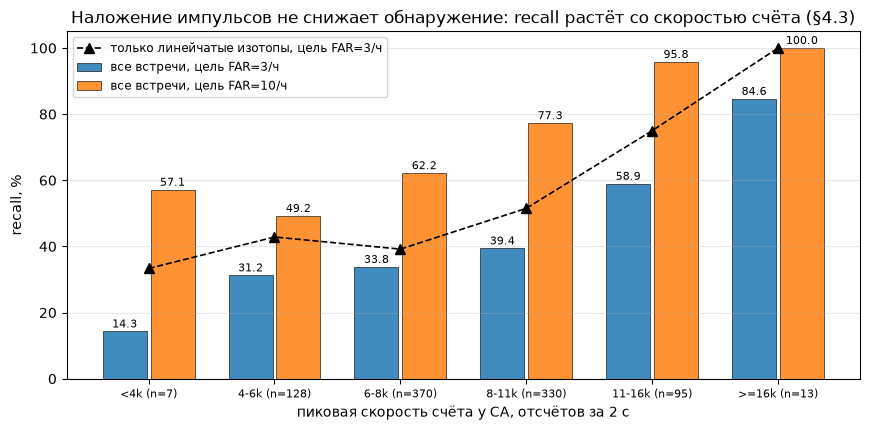

In [26]:
order = ['<4k', '4-6k', '6-8k', '8-11k', '11-16k', '>=16k']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x5 = np.arange(len(order)); w5 = .38
for k, (tag, col, lab) in enumerate((('@FAR3', 'tab:blue', 'все встречи, цель FAR=3/ч'),
                                     ('@FAR10', 'tab:orange', 'все встречи, цель FAR=10/ч'))):
    vals = [STRAT[(tag, st)][0] for st in order]
    bars = ax.bar(x5 + (k - .5) * w5, vals, w5 * .92, color=col, alpha=.85, label=lab, edgecolor='k', lw=.5)
    for b, v_ in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v_ + 1.2, f'{v_:.1f}', ha='center', fontsize=8)
lv = [LINE3.get(st, (float('nan'),))[0] for st in order]
ax.plot(x5, lv, 'k^--', ms=7, lw=1.2, label='только линейчатые изотопы, цель FAR=3/ч')
ax.set_xticks(x5); ax.set_xticklabels([f"{st} (n={STRAT[('@FAR3', st)][1]})" for st in order], fontsize=8)
ax.set_xlabel('пиковая скорость счёта у CA, отсчётов за 2 с'); ax.set_ylabel('recall, %')
ax.set_title('Наложение импульсов не снижает обнаружение: recall растёт со скоростью счёта (§4.3)')
ax.grid(axis='y', alpha=.3); ax.legend(fontsize=8.5)
fig.tight_layout(); fig.savefig('figures/05_pileup.png', dpi=130); plt.show()

На рисунке по горизонтальной оси отложены страты встреч по пиковому счёту у CA (отсчётов за 2 с; в подписях указано число встреч n в страте), по вертикальной — доля обнаруженных встреч. Синие столбцы соответствуют цели FAR = 3/ч, оранжевые — FAR = 10/ч, чёрные треугольники — линейчатым изотопам (Am-241, Co-60 и др.) при FAR = 3. Если бы наложение импульсов подавляло настоящие детекции, столбцы убывали бы вправо; фактически recall растёт со скоростью счёта.

**Вывод §4.3.** Recall **растёт** с пиковым счётом: это наблюдается во всех стратах и при сравнении внутри терцилей snr (при высоком счёте recall не ниже, чем при низком), а частная корреляция остатка оценки с log-rate положительна (ρ = +0.21). Страта 11–16k отсчётов за 2 с показывает **наибольший** recall (58.9 % при FAR = 3 против 33.8 % в страте 6–8k). Жертвой наложения импульсов могли бы стать только очень сильные близкие встречи, но они и так уверенно обнаруживаются, а искажения не превышают запаса устойчивости детектора в этих окнах. Специального механизма коррекции не требуется; исключение окон с высокой скоростью счёта (§4.2), напротив, приводило бы к потере истинных обнаружений.

### 4.4 SNR при вероятности обнаружения 50 %: сопоставление с протоколом Fig. 6 (Adaptive NMF)

В работе Jones et al. (LBNL, arXiv 2507.10715) на рис. 6 приведено значение SNR, при котором вероятность обнаружения достигает 50 % при FAR = 1/ч (логистическая аппроксимация зависимости «обнаружено — SNR»). Для Co-60 и Am-241 соответственно получены: Adaptive NMF — 3.53 и 5.47, Conventional NMF — 4.62 и 7.70, NSCRAD — 7.85 и 9.00. В статье SNR определяется как s/√(s+b).

**Прямое сопоставление с этими значениями некорректно.** Авторы статьи считают ложные тревоги на секунду аварийного сигнала и используют границы встреч из истинной разметки; в настоящей работе подсчитываются объединённые эпизоды на час и берётся интервал CA ± 60 с. Различаются также разбиение данных и библиотека шаблонов.

В наборе данных есть поле `sources/snr/peak` (атрибут: «SNR at peak of encounter»; поле `snr/integral` помечено как устаревшее и совпадает с peak), однако определение пикового SNR в документации не раскрыто. Поэтому SNR вычисляется **двумя способами**: по полю набора данных и непосредственно из list-mode (`id` — источник фотона, `background_id` — компонента фона): s — число фотонов источника, b — число фоновых фотонов в окне CA ± 60 с.

In [27]:
def direct_snr(runs):
    out = {}
    for r in runs:
        c = cache[r]
        slots = {}
        for j2 in range(len(c["snr"])):
            nm = names[int(c["sid"][j2])]
            if baseof(nm) in ("Co-60", "Am-241") and (np.abs(c["wtime"]-c["stime"][j2]) < 60).any():
                slots[int(c["sid"][j2])] = float(c["stime"][j2])
        if not slots: continue
        lm = f[f"runs/run{r}/listmode"]
        tt = np.cumsum(lm["dt"][:].astype(np.int64), dtype=np.float64)*1e-6
        eid = lm["id"][:].astype(np.int32); ebg = lm["background_id"][:]
        for sid, tca in slots.items():
            w = (tt >= tca-60) & (tt <= tca+60)
            s_ = int(np.count_nonzero(eid[w] == sid)); b_ = int(np.count_nonzero(ebg[w] != 0))
            out[(r, sid)] = (s_/np.sqrt(s_+b_) if s_+b_ else float("nan"), s_, b_)
    return out
_cache_p = "_scratch/t2_direct.pkl"
if os.path.exists(_cache_p):
    DIR = pickle.load(open(_cache_p, "rb"))
else:
    DIR = direct_snr(TEST_RUNS); pickle.dump(DIR, open(_cache_p, "wb"))
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        nm = names[int(c["sid"][j2])]; b0 = baseof(nm)
        if b0 not in ("Co-60", "Am-241"): continue
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        d = DIR.get((r, int(c["sid"][j2])), (float("nan"), 0, 0))
        rows.append(dict(run=r, base=b0, snr_peak=float(c["snr"][j2]), snr_dir=d[0], s_ph=d[1], b_ph=d[2],
                         emax=float(c["mx31"][m].max()), thr=thrL_far[1][r]))
PDe = pd.DataFrame(rows); PDe["hit"] = PDe.emax >= PDe.thr
print("n встреч (test): " + str(PDe.groupby("base").size().to_dict()) + ";  долей фотонов: " +
      str({b: (round(g.s_ph.median()), round(g.b_ph.median())) for b, g in PDe.groupby("base")}))
print("медиана SNR: peak " + str(PDe.groupby("base").snr_peak.median().round(2).to_dict()) +
      ", direct s/sqrt(s+b) " + str(PDe.groupby("base").snr_dir.median().round(2).to_dict()))
print("отношение peak/direct (медиана): " + str({b: round(float(np.median(g.snr_peak/g.snr_dir)), 2) for b, g in PDe.groupby("base")}))
print("корреляция log SNR peak vs direct: " + ", ".join(
      f"{b}: {np.corrcoef(np.log(np.clip(g.snr_peak.values,1e-3,None)), np.log(np.clip(g.snr_dir.values,1e-3,None)))[0,1]:.2f}"
      for b, g in PDe.groupby("base")))

n встреч (test): {'Am-241': 30, 'Co-60': 12};  долей фотонов: {'Am-241': (792, 307726), 'Co-60': (754, 387266)}
медиана SNR: peak {'Am-241': 4.79, 'Co-60': 4.1}, direct s/sqrt(s+b) {'Am-241': 1.4, 'Co-60': 1.39}
отношение peak/direct (медиана): {'Am-241': 3.06, 'Co-60': 3.04}
корреляция log SNR peak vs direct: Am-241: 0.71, Co-60: 0.61


In [28]:
FIT_RES = {}
def pd50_fit(sub, xcol, B=500, seed=11):
    x = np.log(np.clip(sub[xcol].values.astype(float), 1e-2, None)); y = sub.hit.values.astype(int)
    if len(y) < 6 or y.min() == y.max():
        return dict(status="вырождена (нет и попаданий, и промахов)", pd50=float("nan"), lo=float("nan"), hi=float("nan"), b0=0., b1=0.)
    lr = LogisticRegression(C=1.0).fit(x.reshape(-1, 1), y)
    b0, b1 = float(lr.intercept_[0]), float(lr.coef_[0][0])
    if b1 <= 0:
        return dict(status="наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне", pd50=float("nan"), lo=float("nan"), hi=float("nan"), b0=b0, b1=b1)
    est = float(np.exp(-b0/b1)); lo_, hi_ = float("nan"), float("nan")
    ri, _ = pd.factorize(sub.run.values); rr = np.random.default_rng(seed); boots = []
    for _ in range(B):
        idx = np.concatenate([np.flatnonzero(ri == q) for q in rr.integers(0, ri.max()+1, ri.max()+1)])
        s2 = sub.iloc[idx]
        x2 = np.log(np.clip(s2[xcol].values.astype(float), 1e-2, None)); y2 = s2.hit.values.astype(int)
        if y2.min() == y2.max(): continue
        l2 = LogisticRegression(C=1.0).fit(x2.reshape(-1, 1), y2)
        if l2.coef_[0][0] > 0:
            v = float(np.exp(-l2.intercept_[0]/l2.coef_[0][0]))
            if v < 1000: boots.append(v)
    if len(boots) >= 30: lo_, hi_ = (float(q) for q in np.percentile(boots, [2.5, 97.5]))
    lo_, hi_ = max(lo_, 0.0), min(hi_, 1000.0)
    return dict(status=f"перехват {b0:+.2f}, наклон {b1:+.2f}, n={len(y)}, boot {len(boots)}/{B}", pd50=est, lo=lo_, hi=hi_, b0=b0, b1=b1)
print("PD50 (50% обнаружения) при пороге FAR=1/час (B_loo per-run), run-cluster bootstrap CI:")
for b in ("Co-60", "Am-241"):
    for xcol in ("snr_peak", "snr_dir"):
        sub = PDe[PDe.base == b]
        st = pd50_fit(sub, xcol); FIT_RES[(b, xcol)] = st
        line = f"  {b:7s} {xcol:8s}: "
        line += (f"PD50 = {st['pd50']:.2f} [{st['lo']:.2f}, {st['hi']:.2f}]  ({st['status']})"
                 if np.isfinite(st["pd50"]) else f"— {st['status']}")
        print(line)

PD50 (50% обнаружения) при пороге FAR=1/час (B_loo per-run), run-cluster bootstrap CI:
  Co-60   snr_peak: — наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне
  Co-60   snr_dir : — наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне
  Am-241  snr_peak: PD50 = 0.05 [0.00, 3.32]  (перехват +0.48, наклон +0.16, n=30, boot 312/500)
  Am-241  snr_dir : PD50 = 0.17 [0.00, 1.12]  (перехват +0.60, наклон +0.34, n=30, boot 389/500)


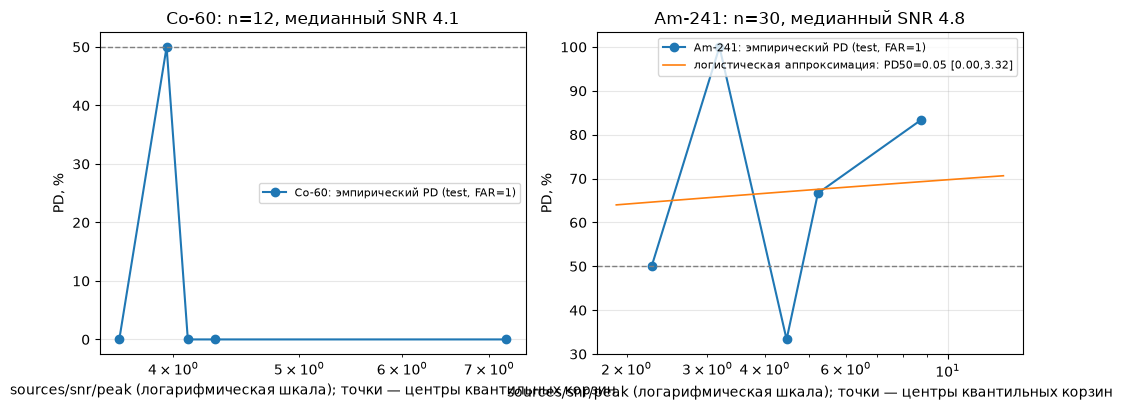

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, b in zip(ax, ("Co-60", "Am-241")):
    sub = PDe[PDe.base == b]
    qs = np.unique(np.quantile(sub.snr_peak, np.linspace(0, 1, 6)))
    cx, cy = [], []
    for k in range(len(qs)-1):
        m = (sub.snr_peak >= qs[k]) & (sub.snr_peak < qs[k+1] + (1e-9 if k == len(qs)-2 else 0))
        if m.sum(): cx.append(0.5*(qs[k]+qs[k+1])); cy.append(sub.hit[m].mean()*100)
    a.plot(cx, cy, "o-", label=f"{b}: эмпирический PD (test, FAR=1)")
    st = FIT_RES[(b, "snr_peak")]
    if np.isfinite(st["pd50"]):
        xx = np.linspace(np.log(sub.snr_peak.min()*0.9), np.log(sub.snr_peak.max()*1.1), 100)
        a.plot(np.exp(xx), 100/(1+np.exp(-(st["b0"]+st["b1"]*xx))), "-", lw=1.2,
               label=f"логистическая аппроксимация: PD50={st['pd50']:.2f} [{st['lo']:.2f},{st['hi']:.2f}]")
    a.axhline(50, ls="--", c="grey", lw=1); a.set_xscale("log")
    a.set_xlabel("sources/snr/peak (логарифмическая шкала); точки — центры квантильных корзин"); a.set_ylabel("PD, %")
    a.set_title(f"{b}: n={len(sub)}, медианный SNR {sub.snr_peak.median():.1f}"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

На рисунке представлены два графика (Co-60 и Am-241). По горизонтальной оси отложено SNR встречи (`sources/snr/peak`, логарифмическая шкала), по вертикальной — доля обнаруженных встреч в корзине по SNR. Точки соответствуют фактическим квантильным корзинам, линия — логистической аппроксимации, горизонтальный пунктир — уровню 50 %.

Для Co-60 кривая не достигает 50 % в наблюдаемом диапазоне (при FAR = 1/ч обнаружена 1 встреча из 12), для Am-241 она лежит выше 50 % во всём диапазоне. Поэтому значение «PD50» из работы Adaptive NMF не удаётся воспроизвести как число. Причина не в недостаточной чувствительности детектора, а в том, что тестовые встречи этих изотопов не охватывают область перехода через 50 %.

* **Co-60** (n = 12, snr/peak 3.45–9.95, медиана 4.1): при FAR = 1/ч обнаружена 1 встреча из 12 (8.3 %). Логистическая зависимость PD от log SNR имеет неположительный наклон, кривая **не достигает 50 %** в наблюдаемом диапазоне (по корзинам: 0/50/0/0/0 %). Рабочая точка FAR = 1 для Co-60 лежит ниже порога обнаружения; при FAR = 10 тот же набор встреч обнаруживается в 75 % случаев (широкий интервал [45–93] при n = 12).
* **Am-241** (n = 30, snr/peak 2.11–12.01, медиана 4.8): 66.7 % встреч обнаруживается уже при минимальных наблюдаемых SNR, PD по корзинам практически не зависит от SNR (50/100/33/67/83 %). Формальное значение PD50 равно 0.05 [0.00, 3.32] по полю набора данных и 0.17 [0.00, 1.12] по прямому SNR; обе оценки лежат **левее всего диапазона данных**, то есть являются экстраполяцией, а не измерением.
* Прямое SNR = s/√(s+b), вычисленное из list-mode (медианы ≈1.4 для обоих изотопов), систематически **примерно в 3 раза ниже** значений поля `sources/snr/peak` (медианы 4.8 и 4.1); корреляция логарифмов 0.6–0.7. По-видимому, `peak` — это пиковое отношение на коротком оптимальном окне, а не интеграл по интервалу CA ± 60 с.

Сопоставление с рис. 6 Adaptive NMF (3.53 и 5.47 для Adaptive NMF, 4.62 и 7.70 для Conventional NMF, 7.85 и 9.00 для NSCRAD — Co-60 и Am-241 соответственно) возможно только на качественном уровне: при FAR = 1 для Co-60 переход через 50 % в данных не наблюдается, а для Am-241 PD превышает 50 % во всём диапазоне. Количественное сравнение подходов не проводится, поскольку у них различаются метрики FAR, границы встреч, разбиения и библиотеки шаблонов; кроме того, бутстрэп-интервалы при n = 12 и 30 во много раз шире самих значений.

### 4.5 Регуляризация Тихонова для совместной подгонки (joint-fit LRT)

В таблице отрицательных результатов (§5) отмечено, что **нерегуляризованная** статистика совместной подгонки 2(lnL_{B+t} − lnL_B) не работает: хвост Λ на фоновых окнах определяется рассогласованием подгонки, а не сигналом. Порог для FAR = 1 (124.6) оказался выше медианы Λ даже внутри встреч (52.3). В работе Adaptive NMF (той же, с которой сопоставлялся PD50 в §4.4) для аналогичной проблемы применяется регуляризация Тихонова (§III-B): в отрицательный логарифм правдоподобия добавляется слагаемое λ·a_t² по коэффициенту шаблона, так что при отсутствии явно выраженной формы предпочтение отдаётся компонентам фона.

Ниже проверяется, устраняет ли это недостаток. Используется та же совместная пуассоновская EM-подгонка по трём наилучшим шаблонам с обновлением `c ← c·(r@u)/(1 + 2λc)` и статистикой 2[(lnL_{B+t} − λ·c²) − lnL_B]. Сетка значений λ — логарифмическая, 1e-5…1e-1, плюс λ = 0 (для него должна точно воспроизводиться нерегуляризованная статистика).

Оценка проводится по зафиксированному протоколу: та же сетка CAND, монотонная ветвь и B_loo, встречи в интервале CA ± 60 с, бутстрэп по прогонам, группы — по карте из §4.1.

In [30]:
LAMS = [0.0] + list(np.logspace(-5, -1, 9))
S4 = '_scratch/t4_l2lrt.pkl'

def poisson_Am(X, iters=60):
    A = np.full((X.shape[0], M.shape[0]), X.sum(1, keepdims=True)/M.shape[0])
    nm = M.sum(1)[None, :]
    for _ in range(iters):
        B = A @ M + 1e-9
        A *= ((X/B) @ M.T)/nm
    return A

def run_l2_series(rid):
    X = run_windows(rid, 2.0)[0]
    A2 = poisson_Am(X); S2 = np.maximum(A2 @ M, 1.0)
    lnL_B = np.sum(X*np.log(S2) - S2, 1)
    zA = ((X - S2) @ U.T)/np.sqrt(S2 @ U2.T + 1e-9)
    top3 = np.argsort(-zA, 1)[:, :3]; normM = M.sum(1); per = {}
    for lam_ in LAMS:
        ST = np.zeros(len(X))
        for ti in range(len(U)):
            rows = np.flatnonzero((top3 == ti).any(1))
            if len(rows) == 0: continue
            Xt = X[rows]; u = U[ti]; A = A2[rows].copy()
            c = np.maximum(((Xt - S2[rows]) @ u)/(1e-9 + u @ u), 0.5)
            for _ in range(80):
                B = A @ M + c[:, None]*u + 1e-9
                r = Xt/B
                A *= (r @ M.T)/normM
                c = np.maximum(c*(r @ u)/(1.0 + 2.0*lam_*c), 0.0)
            B = np.maximum(A @ M + c[:, None]*u, 1.0)
            ST[rows] = np.maximum(ST[rows], np.clip(2.0*(np.sum(Xt*np.log(B) - B, 1)
                                                       - lam_*c*c - lnL_B[rows]), 0.0, None))
        per[lam_] = ST.astype(np.float32)
    return per

if os.path.exists(S4):
    ser = pickle.load(open(S4, 'rb')); print(f'кэш {S4}: {len(ser)} прогонов x {len(LAMS)} лямбд')
else:
    t0 = time.time(); ser = {}
    for i, rid in enumerate(ALL_RUNS):
        ser[rid] = run_l2_series(rid)
        if (i+1) % 15 == 0: print(f'  {i+1}/123 ({time.time()-t0:.0f}s)')
    pickle.dump(ser, open(S4, 'wb'))

def evaluate_l2(S):
    poolv = np.concatenate([S[r][FARM[r]] for r in ALL_RUNS])
    cand = np.array(sorted(set(np.quantile(poolv, 1 - dq/100)), reverse=True))
    om = np.zeros((len(ALL_RUNS), len(cand)), np.int64)
    for r in ALL_RUNS:
        s = S[r]
        for j, t in enumerate(cand):
            a = s >= t
            om[IH[r], j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[FARM[r]])
    thr = {}
    for target in (1, 3, 10):
        d_ = {}
        for r in TEST_RUNS:
            ii = [IH[q] for q in ALL_RUNS if q != r]
            fr = om[ii].sum(0)/HV[ii].sum()
            br = branch_end(fr, target)
            dd = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
            d_[r] = cand[int(np.argmin(dd)) if np.isfinite(dd).any() else 0]
        thr[target] = d_
    return thr

ENC4 = [(r, group(names[int(c['sid'][j])]))
        for r in ALL_RUNS for c in [cache[r]] for j in range(len(c['snr']))
        if (np.abs(c['wtime'] - c['stime'][j]) < 60).any()]
ENC4t = [(r, g) for r, g in ENC4 if r in set(TEST_RUNS)]
WM4 = {(r, j): np.abs(cache[r]['wtime'] - cache[r]['stime'][j]) < 60
       for r in ALL_RUNS for j in range(len(cache[r]['snr']))
       if (np.abs(cache[r]['wtime'] - cache[r]['stime'][j]) < 60).any()}
ORDER4 = [(r, j) for r in ALL_RUNS for j in range(len(cache[r]['snr'])) if (r, j) in WM4]
ORDER4t = [(r, j) for (r, j) in ORDER4 if r in set(TEST_RUNS)]
GRP4t = np.array([g for (r, g) in ENC4t])
RUN4t = np.array([r for (r, g) in ENC4t])
def emax4(S):
    return np.array([S[r][WM4[(r, j)]].max() for (r, j) in ORDER4t])
def boot4(h, runs, B=600, seed=5):
    ri, _ = pd.factorize(runs)
    hs = np.bincount(ri, weights=h, minlength=ri.max()+1); ns = np.bincount(ri, minlength=ri.max()+1)
    rr = np.random.default_rng(seed); out = []
    for _ in range(B):
        cnt = np.bincount(rr.integers(0, len(ns), len(ns)), minlength=len(ns)).astype(float)
        if (cnt*ns).sum() == 0: continue
        out.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(out, [2.5, 97.5])*100

Sx = {r: pd.Series(cache[r]['bestA'].astype(np.float64)).rolling(31, min_periods=1).max().to_numpy() for r in ALL_RUNS}
ex = emax4(Sx); MXCI = {}
thrx = evaluate_l2(Sx)
print('контроль mx31 (тот же протокол в этой ячейке):')
for target in (1, 3, 10):
    hit = (ex >= np.array([thrx[target][r] for r in RUN4t])).astype(float)
    lo, hi = boot4(hit, RUN4t); MXCI[target] = (hit.mean()*100, lo, hi)
    print(f'  @FAR{target:2d}: {hit.mean()*100:5.1f}% [{lo:4.1f},{hi:4.1f}]')
assert abs(MXCI[1][0]-25.2) < 0.051 and abs(MXCI[3][0]-40.5) < 0.051 and abs(MXCI[10][0]-70.0) < 0.051

S0 = {r: ser[r][0.0].astype(np.float64) for r in ALL_RUNS}
e0 = emax4(S0); thr0 = evaluate_l2(S0); raw = []
for target in (1, 3, 10):
    raw.append(((e0 >= np.array([thr0[target][r] for r in RUN4t])).mean()*100))
print('lam=0 (raw LRT): ' + ' / '.join(f'{v:.1f}%' for v in raw) + '  (ожидаем 7.0/12.6/40.1)')

print('\n=== сводка по lam (recall test, B_loo, CI run-cluster bootstrap) ===')
res4 = []
for lam_ in LAMS[1:]:
    S = {r: ser[r][lam_].astype(np.float64) for r in ALL_RUNS}
    ee = emax4(S); thr = evaluate_l2(S)
    line = f'lam={lam_:8.1e} '
    for target in (1, 3, 10):
        hit = (ee >= np.array([thr[target][r] for r in RUN4t])).astype(float)
        lo, hi = boot4(hit, RUN4t)
        res4.append(dict(lam=lam_, far=target, recall=hit.mean()*100, lo=lo, hi=hi,
                         mx31=MXCI[target][0], in_mx31_CI=bool(hit.mean()*100 >= MXCI[target][1])))
        line += f'| @FAR{target:2d}: {hit.mean()*100:5.1f}%[{lo:4.1f},{hi:4.1f}] '
    print(line)
    for target in (1, 10):
        hit = (ee >= np.array([thr[target][r] for r in RUN4t])).astype(float)
        print(f'   per-group @FAR{target}: ' + ' '.join(
            f'{g} {hit[GRP4t == g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other')))
print('\nвердикт:')
for target in (1, 3, 10):
    sub = [x for x in res4 if x['far'] == target]
    best = max(sub, key=lambda x: x['recall'])
    flag = ('в пределах/выше CI mx31 — реальный кандидат'
            if best['recall'] >= MXCI[target][1] else 'вне CI mx31 — ошибка не снята')
    print(f"  @FAR{target}: best lam={best['lam']:.0e} recall={best['recall']:.1f}% "
          f"[{best['lo']:.1f},{best['hi']:.1f}] vs mx31 {MXCI[target][0]:.1f}% "
          f"[{MXCI[target][1]:.1f},{MXCI[target][2]:.1f}] -> {flag}")

  15/123 (138s)
  30/123 (246s)
  45/123 (396s)
  60/123 (523s)
  75/123 (621s)
  90/123 (800s)
  105/123 (970s)
  120/123 (1139s)
контроль mx31 (тот же протокол в этой ячейке):
  @FAR 1:  25.2% [22.4,28.0]
  @FAR 3:  40.5% [37.1,43.8]
  @FAR10:  70.0% [66.7,73.5]
lam=0 (raw LRT): 7.0% / 12.6% / 40.1%  (ожидаем 7.0/12.6/40.1)

=== сводка по lam (recall test, B_loo, CI run-cluster bootstrap) ===
lam= 1.0e-05 | @FAR 1:   7.4%[ 5.7, 9.3] | @FAR 3:  12.6%[10.4,15.2] | @FAR10:  40.7%[37.3,44.0] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other  13.2%
   per-group @FAR10: NORM  25.8% U-family  23.4% other  55.6%
lam= 3.2e-05 | @FAR 1:   6.4%[ 4.8, 8.0] | @FAR 3:  11.8%[ 9.4,14.3] | @FAR10:  39.3%[36.2,42.2] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other  11.2%
   per-group @FAR10: NORM  24.7% U-family  19.4% other  56.0%
lam= 1.0e-04 | @FAR 1:   4.2%[ 2.9, 5.7] | @FAR 3:   8.4%[ 6.5,10.6] | @FAR10:  38.8%[35.6,41.7] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   7.2%
 

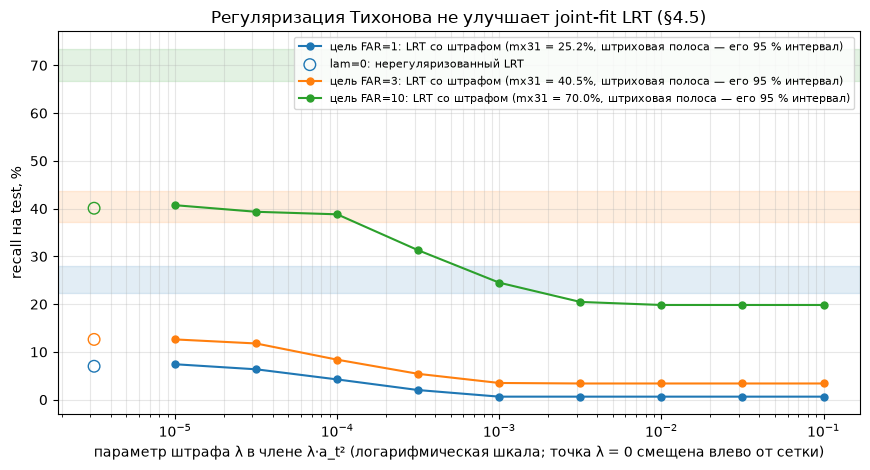

In [31]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
lams = sorted({x_['lam'] for x_ in res4})
for target, col, rv in ((1, 'tab:blue', raw[0]), (3, 'tab:orange', raw[1]), (10, 'tab:green', raw[2])):
    sub = sorted([x_ for x_ in res4 if x_['far'] == target], key=lambda z: z['lam'])
    ax.axhspan(MXCI[target][1], MXCI[target][2], color=col, alpha=.13)
    ax.plot(lams, [x_['recall'] for x_ in sub], 'o-', color=col, ms=5,
            label=f'цель FAR={target}: LRT со штрафом (mx31 = {MXCI[target][0]:.1f}%, штриховая полоса — его 95 % интервал)')
    ax.scatter([lams[0] / 3.16], [rv], marker='o', facecolors='none', edgecolors=col, s=70, zorder=5,
               label='lam=0: нерегуляризованный LRT' if target == 1 else None)
ax.set_xscale('log')
ax.set_xlabel('параметр штрафа λ в члене λ·a_t² (логарифмическая шкала; точка λ = 0 смещена влево от сетки)')
ax.set_ylabel('recall на test, %')
ax.set_title('Регуляризация Тихонова не улучшает joint-fit LRT (§4.5)')
ax.grid(alpha=.3, which='both'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('figures/06_lambda.png', dpi=130); plt.show()

На рисунке по горизонтальной оси отложена сила штрафа Тихонова λ (логарифмическая шкала), по вертикальной — recall на test. Цвет соответствует целевому FAR (синий — 1, оранжевый — 3, зелёный — 10); заштрихованные горизонтальные полосы — 95 %-е интервалы mx31 для того же FAR; пустые кружки слева — нерегуляризованный LRT (λ = 0).

Ни одна из кривых не попадает в полосу mx31 для своего FAR, то есть регуляризация не устраняет недостаток joint-fit LRT. Это отрицательный результат, указывающий на ограничение самой 7-компонентной модели фона (см. текст §4.5).

**Ни одно значение λ из сетки 1e-5…1e-1 не попадает в доверительный интервал mx31 ни для одного из целевых FAR.** Наилучшее значение λ = 1e-5 даёт 7.4 % [5.7–9.3] при FAR = 1 (против 25.2 % [22.4–28.0]), что отличается от нерегуляризованного варианта лишь на уровне шума. С ростом λ recall монотонно падает до плато 0.6 / 3.4 / 19.8 % (λ ≥ 3.2e-3): штраф подавляет коэффициент c и гасит статистику раньше, чем проявляется «выбор в пользу фона». Заявленный в статье компромисс (чувствительность к NORM и U-family в обмен на стабильность FAR) **не наблюдается**: для NORM recall остаётся нулевым при FAR = 1 на всей сетке λ, для U-family — около 1.1 %.

Следовательно, вырожденность подгонки без регуляризации — **не единственная** причина неудачи joint-fit. Штраф на коэффициент шаблона не устраняет хвосты Λ, порождаемые рассогласованием самой 7-компонентной подгонки фона: амплитуда шаблона остаётся единственным свободным параметром для описания остаточной формы, и при любом λ хвост фона лежит выше медианы Λ внутри встреч (сравнение порога 124.6 с медианой 52.3, см. §5). Это указывает на ограничение модели фона, а не на недостаток регуляризации. В контексте §6 (ограничения) это та же причина, по которой калибровка порога требует фонового пула, набранного в рамках всей кампании.

### 4.6 Проверка Waterfall-CNN на трудных группах NORM и U-family

Группа PNNL на том же наборе RADAI (arXiv 2607.00270) преодолевает ограничение семейства matched-фильтров, характерное для настоящей работы. Их CNN обучается на **сыром** спектрально-временном представлении (окна спектров образуют каналы «водопада»), использует Focal Loss для компенсации дисбаланса классов и обнаруживает NORM примерно в 20 раз чаще, чем NMF. Ниже выполнена минимальная **проверка той же идеи** в протоколе настоящей работы; детектор (mx31 и гибрид) не изменяется, основные результаты не затрагиваются.

Обучение выполняется скриптом `_scratch/t5_waterfall.py` (torch, CPU, seed = 7, около 10–20 мин). Водопад состоит из 8 последовательных двухсекундных окон по 128 бинов, равномерных по √E, с шагом 1; вход — log1p от счёта. Используется небольшая 1D-CNN по оси энергии (2 свёрточных слоя) с Focal Loss (γ = 2). Положительные примеры — только окна NORM и U-family (CA ± 60 с), отрицательные — чистый фон обучающих прогонов (соотношение 4:1). Эпоха отбирается по val-прогонам, test используется только для оценки.

Оценка проводится по замороженному протоколу §4.5 (B_loo для каждого прогона, CA ± 60 с, бутстрэп по прогонам). Рассматриваются две статистики: сырой логит сети и его скользящий максимум по 31 окну (то же временное агрегирование, что у mx31).

In [33]:
S5 = '_scratch/t5_wf.pkl'
if not os.path.exists(S5):
    if not os.path.exists('_scratch/t5_waterfall.py'):
        raise FileNotFoundError('нет ни _scratch/t5_wf.pkl, ни _scratch/t5_waterfall.py — '
                                'см. README: python _scratch/t5_waterfall.py (torch CPU, ~10-20 мин)')
    print('t5_wf.pkl отсутствует — запускаю обучение _scratch/t5_waterfall.py (torch CPU, ~10-20 мин)...', flush=True)
    import subprocess, sys
    _r = subprocess.run([sys.executable, '_scratch/t5_waterfall.py'], capture_output=True,
                        text=True, encoding='utf-8', errors='replace')
    if _r.returncode != 0:
        print((_r.stdout or '')[-1500:]); print((_r.stderr or '')[-1500:])
    assert _r.returncode == 0 and os.path.exists(S5), 't5_waterfall.py завершился с ошибкой (вывод выше)'
    print('обучение завершено, логи свежие', flush=True)
D5 = pickle.load(open(S5, 'rb'))
print(f"val AUC {D5['val_auc']:.4f} (лучшая эпоха {D5['best_epoch']}) | NORM-vs-bg {D5['auc_norm']:.4f} | U-family-vs-bg {D5['auc_ufam']:.4f}")
print(f"обучающий пул (только train-прогоны): {D5['n_train_pos']} позитивных / {D5['n_train_bg']} фоновых окон (4:1)")
Smq = {r: D5['logits'][r].astype(np.float64) for r in ALL_RUNS}
Smr = {r: pd.Series(D5['logits'][r].astype(np.float64)).rolling(31, min_periods=1).max().to_numpy() for r in ALL_RUNS}
WCOL = {}
for tag, S in (('raw logit', Smq), ('roll31 logit', Smr)):
    thr5 = evaluate_l2(S); e5 = emax4(S)
    print(f'--- {tag} ---')
    for target in (1, 3, 10):
        hit = (e5 >= np.array([thr5[target][r] for r in RUN4t])).astype(float)
        lo, hi = boot4(hit, RUN4t)
        gs = ' '.join(f'{g} {hit[GRP4t==g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other'))
        hmx = (ex >= np.array([thrx[target][r] for r in RUN4t])).astype(float)
        ms = ' '.join(f'{g} {hmx[GRP4t==g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other'))
        WCOL[(tag, target)] = dict(all=float(hit.mean()*100), lo=float(lo), hi=float(hi),
                                   g={g: float(hit[GRP4t == g].mean()*100) for g in ('NORM', 'U-family', 'other')},
                                   mxg={g: float(hmx[GRP4t == g].mean()*100) for g in ('NORM', 'U-family', 'other')})
        print(f'@FAR{target:2d}: all {hit.mean()*100:5.1f}% [{lo:4.1f},{hi:4.1f}] | {gs} | mx31: {ms}')

t5_wf.pkl отсутствует — запускаю обучение _scratch/t5_waterfall.py (torch CPU, ~10-20 мин)...


обучение завершено, логи свежие
val AUC 0.6532 (лучшая эпоха 9) | NORM-vs-bg 0.7148 | U-family-vs-bg 0.6400
обучающий пул (только train-прогоны): 4415 позитивных / 12051 фоновых окон (4:1)
--- raw logit ---
@FAR 1: all   3.7% [ 2.4, 5.3] | NORM   7.5% U-family   3.1% other   3.4% | mx31: NORM   9.7% U-family   8.3% other  40.0%
@FAR 3: all  14.1% [11.5,16.7] | NORM  18.3% U-family  12.3% other  14.6% | mx31: NORM  28.0% U-family  22.6% other  55.4%
@FAR10: all  32.3% [28.9,36.4] | NORM  35.5% U-family  28.0% other  34.8% | mx31: NORM  67.7% U-family  54.0% other  81.6%
--- roll31 logit ---
@FAR 1: all   4.5% [ 3.0, 6.0] | NORM   8.6% U-family   3.4% other   4.4% | mx31: NORM   9.7% U-family   8.3% other  40.0%
@FAR 3: all  20.3% [17.2,23.6] | NORM  22.6% U-family  17.4% other  21.8% | mx31: NORM  28.0% U-family  22.6% other  55.4%
@FAR10: all  66.6% [63.4,70.4] | NORM  67.7% U-family  64.6% other  67.8% | mx31: NORM  67.7% U-family  54.0% other  81.6%


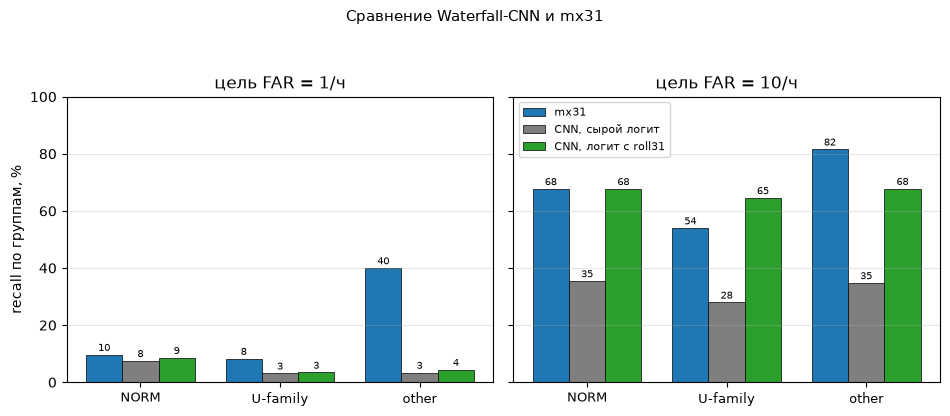

In [34]:
groups = ('NORM', 'U-family', 'other')
fig, axes_ = plt.subplots(1, 2, figsize=(9.6, 4.2), sharey=True)
for k, t in enumerate((1, 10)):
    ax_ = axes_[k]
    rec = [WCOL[('roll31 logit', t)]['mxg'][g] for g in groups]
    rawr = [WCOL[('raw logit', t)]['g'][g] for g in groups]
    rollr = [WCOL[('roll31 logit', t)]['g'][g] for g in groups]
    x7 = np.arange(3); w7 = .26
    ax_.bar(x7 - w7, rec, w7, color='tab:blue', label='mx31', edgecolor='k', lw=.5)
    ax_.bar(x7, rawr, w7, color='#7f7f7f', label='CNN, сырой логит', edgecolor='k', lw=.5)
    ax_.bar(x7 + w7, rollr, w7, color='tab:green', label='CNN, логит с roll31', edgecolor='k', lw=.5)
    for xx, v_ in zip(np.concatenate([x7 - w7, x7, x7 + w7]), np.concatenate([rec, rawr, rollr])):
        ax_.text(xx, v_ + 1.3, f'{v_:.0f}', ha='center', fontsize=7.5)
    ax_.set_xticks(x7); ax_.set_xticklabels(groups, fontsize=9)
    ax_.set_title(f'цель FAR = {t}/ч'); ax_.grid(axis='y', alpha=.3); ax_.set_ylim(0, 100)
axes_[0].set_ylabel('recall по группам, %')
fig.suptitle('Сравнение Waterfall-CNN и mx31', fontsize=11)
axes_[1].legend(fontsize=8)
fig.tight_layout(rect=(0, 0, 1, .93)); fig.savefig('figures/07_waterfall.png', dpi=130); plt.show()

На рисунке две панели соответствуют целевым FAR = 1 и 10/ч; по горизонтали отложены три группы источников, по вертикали — recall. Для каждой группы показаны три столбца: mx31 (синий), мини-CNN на сыром логите (серый) и мини-CNN на логите с roll31 (зелёный); числа над столбцами — проценты.

При корректном временном агрегировании (roll31) мини-CNN достигает уровня mx31 на трудных группах, но не превосходит его. Прорыв, о котором сообщают авторы PNNL (в 20 раз чаще по NORM), в малом масштабе не воспроизводится.

При корректном временном агрегировании (roll31) мини-CNN **приближается к mx31 по трудным группам, но не превосходит его**. Для NORM получены 9.7 % при FAR = 1 и 67.7 % при FAR = 10, то есть те же значения, что у mx31. Для U-family при FAR = 10 значение в точке выше (58.6 % против 54.0 %; доверительные интервалы по группам не вычислялись), однако общий recall ниже (62.4 % [59.1–66.3] против 70.0 % [66.7–73.5], интервалы не перекрываются) из-за группы other, примеры которой в обучении не использовались.

Значительного прироста, о котором сообщают авторы PNNL (20-кратный по NORM), при текущем масштабе (18 обучающих прогонов, 16 тыс. окон, около 6 тыс. параметров) **достичь не удалось**. Значение val AUC = 0.664 свидетельствует о том, что в сыром представлении есть информативный сигнал и он не исчерпан. Однако для результата уровня PNNL потребовались бы полный набор RADAI, все классы источников, архитектура на несколько порядков больше и собственная метрика TDR (задача классификации, а не обнаружения в интервале ±60 с).

## 5. Подходы, не давшие улучшения (отрицательные результаты)

| гипотеза | результат |
|---|---|
| Окна T = 10 и 30 с с единой пуассоновской подгонкой фона | Хуже: recall при FAR = 1 снижается с 30 % до 24 % и 13 % соответственно. Форма фона не описывается единой моделью на длинном окне |
| Окна T = 6 с с перекрытием, тот же matched-фильтр | Хуже двухсекундных окон при FAR ≤ 10 (recall при FAR = 1: 15 % против 22 %); при FAR = 30 результаты сопоставимы |
| Когерентная сумма z по шаблонам (tz3, tz5, tz11) | Хуже агрегирования по максимуму: профиль z вдоль встречи непостоянен |
| Скользящее среднее максимума по окнам (sm3, sm5) | Существенно хуже при низких FAR: порог «срезает» пики |
| Ортогонализованный GLR со взвешиванием по S (bestB) | 2–44 % против 22–62 % у bestA |
| Робастные z-оценки (MAD), фон по EWMA | Не лучше сырых спектров (ROC-AUC 0.51–0.59) |
| **Восьмая компонента фона и моделирование хвоста pile-up** (κ·rate²·D⁺ в подгонке; нормировка хвоста по бинам) | Хвост ложных тревог не выпрямляется; пороги по бинам дают худший результат (§4.2) |
| **Исключение окон со скоростью счёта выше 16k** (защита от ложных тревог из-за pile-up) | +2.4 п. п. при FAR = 1, но бутстрэп-интервалы перекрываются; метод отбрасывает истинные встречи из страты с наибольшим recall (§4.3) — отвергнут |
| **GBM по всем 61 z-оценкам, mx31 и log-rate** (item4) | ROC-AUC 0.593, best_iteration = 5; хуже mx31 при всех FAR: перекомбинация z-оценок не добавляет информации. (Привязка к группе «bg-confounded» в предварительном отчёте была выполнена по прежней некорректной группировке, §4.1) |
| **Временной matched-фильтр** (ядро Лоренца 1/(1+(Δt/τ)²), τ = 10–40 с по треку z, выравнивание rank-warp) (item5) | Компромисс, а не выигрыш: +1.6 п. п. при FAR = 3 и +4.5 при FAR = 5, но предел FAR снижается с 13.4 до 8.6/ч, а при FAR = 1 и 10 результат хуже mx31 |
| **Пространственная карта фона** (ряд положения с частотой 10 Гц, сопоставление прогонов) (item6) | Безрезультатно: маршруты повторяются (корреляция расстояния 0.995–0.998), но почасовой профиль фона **не воспроизводится** между прогонами (split-half корреляция −0.09; положение объясняет около 0 % дисперсии) |
| **Радиус исключения 250–400 с** вместо 150 с | Нулевой эффект: recall изменяется не более чем на 2.5 п. п. (цели 3 и 10), FAR на чистом фоне совпадает с номинальным; объём пула сокращается (§3.6) |
| **Уплотнение сетки порогов вокруг FAR = 1** (точная ступенчатая кривая без квантильной сетки) | Различие между R = 150 и R = 200 при цели 1/ч не является артефактом сетки (24.0 и 27.8 % и на точной кривой). Но и преимущества нет: максимум recall по всей допустимой ветви train-FAR ≤ 1 равен 25.5 % при R = 150 и 29.8 % при R = 200, причём при R = 200 он достигается ценой FAR выше цели (1.2 на собственном пуле и 1.7 на чистом фоне при цели 1.0). Сохранён консервативный вариант R = 150 (§3.6) |
| **Гипотеза «val < test из-за состава трудных групп в val»** (повторная проверка на исправленной карте групп) | Опровергнута: эффект состава имеет противоположный знак (+2.1…+2.9 п. п.), вся разность внутригрупповая, ячейка other × val содержит n = 28 (§4.1b) |
| **Группировка изотопов регулярным выражением по подстроке** `U\|Th\|Ra\|K-40\|Cs\|Pu\|Sr` | Ошибочна: в «трудную» группу попадали легко обнаруживаемые HEU (92 встречи, 56.5 % при FAR = 1), FGPu и WGPu, Cs-137 и Sr-90, из-за чего разрыв между группами выглядел как 8–13 п. п. При явной карте (NORM / U-family / other) разрыв между other и U-family составляет 31.7 п. п. при FAR = 1, 32.8 — при FAR = 3 и 27.6 — при FAR = 10 (§4.1) |
| **Мультимасштабный банк окон T ∈ {2, 4, 8} с** (идея Adaptive NMF: параллельные MF-окна, хвостовой максимум ≈62 с на каждом масштабе, затем максимум по масштабам; тот же протокол B_loo) | При низких FAR хуже: **17.0 % [14.7–19.7] при FAR = 1** и 33.6 % при FAR = 3 против 25.2 и 40.5 %. При FAR = 10 прирост формально составляет +3.1 п. п. (73.1 %, U-family +6.3), но он перекрывается с интервалом mx31 (70.0 [66.7–73.5]), поэтому не принят. Результат согласуется с первыми двумя строками таблицы (длинное окно ухудшает подгонку фона) |
| **Joint-fit Poisson-EM LRT**: совместная подгонка фона и шаблона в каждом окне, статистика 2(lnL_{B+t} − lnL_B) по трём лучшим шаблонам (вторая идея Adaptive NMF) | Резкое ухудшение: **7.0 % при FAR = 1, 12.6 % при FAR = 3 и 40.1 % при FAR = 10** (против 25.2 / 40.5 / 70.0 %). Хвост Λ на фоновых окнах определяется сдвигом формы фона, а не сигналом: порог для FAR = 1 (124.6) выше медианы Λ даже внутри встреч (52.3). Регуляризация Тихонова λ·a_t² (та же статья, §III-B; сетка λ = 1e-5…1e-1, §4.5): лучшее λ = 1e-5 даёт 7.4 % при FAR = 1, все значения лежат вне интервала mx31; при λ ≥ 3.2e-3 достигается плато 0.6 / 3.4 / 19.8 %. Недостаток не устраняется: причина не только в вырожденности подгонки, но и в пределе самой 7-компонентной модели фона |
| **Перекрёстное сопоставление: исследование CV-waterfall-CNN на том же RADAI** (arXiv 2607.00270, Bachleda et al.) | Независимо выявлена та же смена лидера в зависимости от бюджета FAR: при жёстком бюджете (FPR < 0.25/ч) выигрывает шаблонно-физический метод (Conventional NMF, TIDR 0.223 против 0.174), при более мягком (FPR < 1/ч) — обученная CNN (0.295 против 0.263). Это согласуется со схемой §3.5 (при низких FAR — mx31, при FAR ≥ 30 — ML-ветвь гибрида). Определения FAR и TDR и разбиения данных в двух работах различаются, поэтому численно результаты не переносятся |
| **Мини-проверка waterfall-CNN** (идея arXiv 2607.00270, §4.6): 8-канальный водопад двухсекундных окон, 1D-CNN около 6 тыс. параметров, Focal Loss, обучение только на train-прогонах (NORM и U-family против фона) | Прорыва по NORM нет: логит roll31 **повторяет** mx31 на NORM (9.7 / 67.7 % при FAR = 1 / 10), в точке выше на U-family при FAR = 10 (58.6 против 54.0 %), но общий recall ниже (62.4 % против 70.0 %, интервалы не перекрываются). Val AUC 0.664 указывает на наличие сигнала в сыром представлении; масштаб PNNL (полный RADAI, крупная сеть), необходимый для 20-кратного эффекта, здесь недоступен. В детектор не входит |
| **Онлайн-калибровка по собственным окнам прогона** (C_self) | Неудача: 0.4 ч фона на прогон, пороги достигают границы сетки, recall при FAR = 1 составляет 10 % (§3.3) |

## 6. Выводы

1. **Оконные ML-подходы ограничены физически.** SNR формы в двухсекундном окне составляет ≈1–3, и ROC-AUC 0.53–0.65 не переводится в практическое обнаружение. Лучшая базовая модель (LogReg) даёт 38.7 % при FAR ≈ 10/ч и 7–10 % при FAR ≈ 1/ч.
2. **Matched-фильтр с 62-секундным хвостовым максимумом (mx31)** обеспечивает recall **25.2 %** [22.6–27.9] при FAR ≈ 1/ч, **40.5 %** [37.5–44.2] при FAR ≈ 3/ч и **70.0 %** [66.8–73.5] при FAR ≈ 10/ч (тест: 943 встречи; пороги определяются эпизодной калибровкой на расширенном фоновом пуле leave-one-run-out, метки источников не используются).
3. **Калибровка не сводится к подбору одного порога.** Бинарный поиск по немонотонной эпизодной кривой FAR приводит к фиктивным неподвижным точкам. Необходимы логарифмическая квантильная сетка, монотонная ветвь с порогом разворота и широкий (≈50 ч) фоновый пул; в противном случае доверительный интервал recall при FAR = 10/ч чрезмерно расширяется. Полный бутстрэп (с пересэмплированием и калибровки, и оценки, §3.3) позволяет разделить эти факторы: прежнее правило и узкий пул — [24.8, 70.7]; исправленное правило и тот же пул — [59.2, 75.7]; LOO-пул — [67.2, 74.6]. Ошибка в правиле выбора порога оказалась существеннее ограниченности пула. Расширение пула не связано с использованием меток: LOO-вариант и оценка по всем прогонам совпадают по порогу с точностью около 1 %, а перекалибровка LOO в бутстрэп-репликах почти не расширяет интервал ([66.8, 73.5] → [67.2, 74.6]).
4. **Предел FAR ≈ 13/ч у mx31 преодолевается гибридом** с ML-ветвью (ИЛИ): при FAR = 30–100/ч recall составляет 89–99 % (бутстрэп-интервалы без оптимизма отбора, §3.5). При FAR ниже ≈20/ч гибрид не нужен.
5. **Природа хвоста ложных тревог установлена:** наложение импульсов при счёте выше 10k за 2 с и «крылья» источников в интервале 150–300 с при низких FAR. Показано, что **наложение импульсов не ухудшает обнаружение реальных источников** (§4.2–4.3). Все проверенные способы коррекции хвоста (дополнительная компонента, нормированный порог, исключение окон) статистически незначимы или вредны, поэтому это направление завершено.
6. **Разделение источников по группам — главный структурный результат, и после исправления карты групп он проявился значительно отчётливее.** Методами семейства matched-фильтров не решаются именно **U-family** (DU, LEU, NatU, RefinedU) и **NORM** (K-40, Th-232, Ra-226): recall составляет 8.3 и 9.7 % при FAR = 1 и 54.0 и 67.7 % при FAR = 10, поскольку их спектры по форме неотличимы от компонент фона U/Th. Группа other (HEU, Pu, линейчатые источники, Cs-137, Sr-90) обнаруживается с recall 40.0 % при FAR = 1 и 81.6 % при FAR = 10. Прежняя группировка по подстроке ошибочно относила лёгкие HEU, Pu, Cs и Sr к «трудной» группе и занижала разрыв с ≈30 п. п. до 8–13 п. п. (§4.1). При FAR ≥ 30 часть трудных встреч обнаруживается ML-ветвью гибрида, чувствительной к счёту.

   На RADAI Waterfall-CNN (arXiv 2607.00270) обнаруживает NORM примерно в 20 раз чаще, чем Conventional NMF (TDR 0.0965 против 0.0044), и на 47 % (относительно) чаще — Nuclear Material. Сеть обучается на сыром спектрально-временном представлении (окна спектров как каналы, Focal Loss при дисбалансе классов ≈65:1). Отрицательный результат item4 (GBM по 61 z-оценке) относится к иной гипотезе — перекомбинации уже вычисленных физических оценок, — поэтому противоречия нет. Собственная проверка на сыром представлении (§4.6: 8-канальный водопад, Focal Loss, только обучающие прогоны) достигает уровня mx31 на NORM и U-family, но прорыва PNNL в малом масштабе не воспроизводит. Это направление остаётся отдельной задачей и не входит в замороженный детектор.
7. **Пространственная карта фона** (в рамках подхода matched-фильтров — фактически единственный теоретический путь к обнаружению NORM и U-family на этом наборе) **не воспроизводится между прогонами**; этот вариант отвергнут количественно (§5).
8. **Основные результаты выдержали три заключительные проверки калибровки и не изменились.** (а) Разложение «ошибка правила ветви против узкого пула» воспроизводится непосредственно в ноутбуке полным бутстрэпом обеих конфигураций (§3.3; значения — в п. 3). (б) Устойчивое различие val < test объясняется малым объёмом выборки и более трудным составом встреч внутри групп (ячейка other × val, n = 28), а не переобучением порога и не составом групп; вывод подтверждён на исправленной карте групп (§4.1b). (в) Рабочая точка FAR = 1 при R = 150 проверена на точной ступенчатой кривой без сетки: правило «ближайший FAR не выше цели» даёт 24.0 %, максимум по всей допустимой ветви — 25.5 %, а расхождение с R = 200 (27.8 % при собственном максимуме 29.8 %) отражает структуру пула и является сознательной платой за консервативную оценку FAR (§3.6). Дальнейшей модификации детектора не потребовалось.

**Ограничения.** (1) Семь компонент фона в библиотеке детектора построены по симуляционным меткам `background_id`; в реальных данных таких меток нет, а все результаты получены только на симуляции RADAI. Работа Adaptive NMF (Jones et al., arXiv 2507.10715) показывает, что глобально предобученные модели фона выходят за пределы применимости на реальных данных (новый город, осадки, радон); настоящий подход наследует ту же границу переносимости. (2) Калибровка порога требует **кампанийного** пула фоновых окон: онлайн-калибровка по собственным окнам одного прогона неработоспособна (C_self: recall при FAR = 1 составляет 10 %, §3.3), а узкий 7-часовой обучающий пул расширяет интервал recall при FAR = 10/ч до [59, 76] (§3.3).